In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.widgets import RangeSlider
from ipywidgets import interact, IntSlider, SelectionSlider
import requests
import warnings
from adjustText import adjust_text
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, q_stat
from arch.unitroot import PhillipsPerron
import statsmodels.api as smf
from IPython.display import display, Markdown, HTML
from sklearn.decomposition import PCA
import mpl_bsic as bsic
import mpl_bsic.style_excel as se
se.HEADER_FMT["font_color"] = se.HEADER_FMT.pop("color")


warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pandas")

from pricing.pricer import PricerClass
from itertools import combinations
from calibration import Calibration
from tradescreener import tradeScreener
from plotting_utils import residuals_actualFitted, multipleResiduals, actualVsFittedCurve, \
    fittingErrorsHeatmap, threeFactorPlot, twoFactorPlot, factorsForwardsPlot, fittingErrorsHeatmap_fwd, \
    currentErrorsHeatmap_fwd

In [3]:
data = pd.read_csv("data/bankofengland/nominal/bankofengland_gilt_filtered.csv", index_col =0, parse_dates=True)
data = data.drop('0.75', axis=1)

Unfortunately, the 0.75y datapoint is missing for a few weeks in the recent period, so we drop it.

In [4]:
bankrate =pd.read_csv("data/bankofengland/bankrate.csv")
bankrate["Date"] = pd.to_datetime(bankrate["Date"], format="%d %b %y")
bankrate.columns = ['date', 'short']
bankrate.set_index('date', inplace=True)
bankrate.index = pd.to_datetime(bankrate.index)
bankrate.sort_index(inplace=True)

In [5]:
zeroCouponYields = pd.merge(bankrate, data, left_index=True, right_index=True, how = 'inner')
zeroCouponYields.columns = ['short'] + [float(x) for x in zeroCouponYields.columns if x != 'short']
zeroCouponYields.sort_index(inplace=True)

### 1. Calibration from 2014 to 2022, on yields below 25 yrs

We fit on yields from 1 to 5 years in breaks of 6 months and on yields above 5 years in breaks of 1 year. I also tried with the whole term structure in breaks of 6 months but the fit was terrible. 

In [ ]:
sampleDates = ('2014-01-01', '2022-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 26)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [ ]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2022.maturities[0], 'to', cal_2022.maturities[-1], 'years.')

best_alpha_2022 =cal_2022.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2022 = cal_2022.calibrateSigma(alpha_r = best_alpha_2022['alpha_r'], 
                                alpha_m = best_alpha_2022['alpha_m'], 
                                alpha_l = best_alpha_2022['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2022 = cal_2022.calibrateMu(alpha_r = best_alpha_2022['alpha_r'], 
                          alpha_m = best_alpha_2022['alpha_m'], 
                          alpha_l = best_alpha_2022['alpha_l'], 
                          sigma_m = best_sigma_2022['sigma_m'], 
                          sigma_l = best_sigma_2022['sigma_l'], 
                          rho = best_sigma_2022['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2014-01-02 and 2021-12-31
Using maturities from 1.0 to 25 years.


KeyboardInterrupt: 

#### 1.1 Inspecting calibration fit

In [ ]:
empiricalAlpha = np.vstack([x for x in cal_2022.regression()])
modelImpliedAlpha = np.vstack([[cal_2022.alphaComparison(tau = x, alpha_r = best_alpha_2022['alpha_r'], 
                                                         alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'])] for x in cal_2022.maturities])

comparisonDf_2y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 0], 'model implied': modelImpliedAlpha[:, 0]}).set_index('spot maturity')
comparisonDf_10y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 1], 'model implied': modelImpliedAlpha[:, 1]}).set_index('spot maturity')

Text(0.5, 0.98, 'Model implied (given best alpha) vs empirical betas from regression')

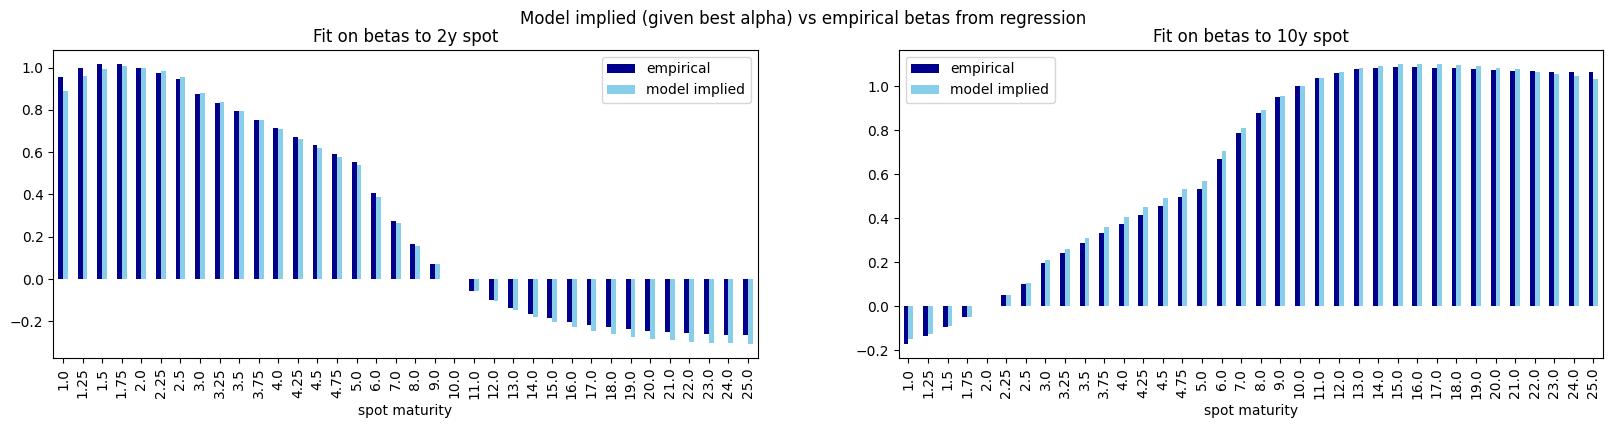

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20,4))
comparisonDf_2y.plot(kind = 'bar', ax=ax[0], title = f'Fit on betas to {int(cal_2022.fairly_priced[0])}y spot', color= ['darkblue', 'skyblue'])
comparisonDf_10y.plot(kind = 'bar', ax=ax[1], title = f'Fit on betas to {int(cal_2022.fairly_priced[1])}y spot', color= ['darkblue', 'skyblue'])
fig.suptitle("Model implied (given best alpha) vs empirical betas from regression")

In [ ]:
empiricalSigma = np.array([cal_2022.empiricalVariance(tau = x, alpha_r=best_alpha_2022['alpha_r']) for x in cal_2022.maturities])
modelImpliedSigma = np.array([cal_2022.modelImpliedVariance(
    tau = x, alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
    sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho']) for x in cal_2022.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2022.maturities, 
                                   'empirical': empiricalSigma, 
                                   'model implied': modelImpliedSigma}).set_index('spot maturity')

<Axes: title={'center': 'Fit on variances of each yield'}, xlabel='spot maturity'>

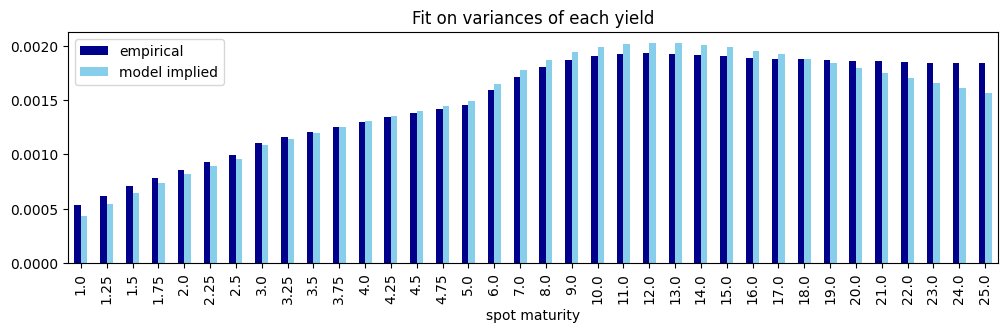

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,3))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, title = f'Fit on variances of each yield', color= ['darkblue', 'skyblue'])

#### 1.2. Inspecting Extrapolated Factors

To get OOS extracted factors, we re-feed the calibration class with the full dataset. We've calibrated all parameters on the in-sample piece of the data, so now we can operate on the full dataset to get OOS results.

In [ ]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 25)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [ ]:
lf_full_2022 = cal_2022.extractLatentFactors_fwd(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
                         sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

estFactorsDf_full_2022 = pd.DataFrame(lf_full_2022, columns = ['medium', 'long'], index = zeroCouponYields[sampleDates[0]:None].index)
estFactorsDf_full_2022['short'] = termStructurePath['short']
estFactorsDf_full_2022 = estFactorsDf_full_2022[['short', 'medium', 'long']]
estFactorsDf_full_2022.iloc[-1]

short     3.750000
medium    1.637214
long      7.099623
Name: 2026-03-31 00:00:00, dtype: float64

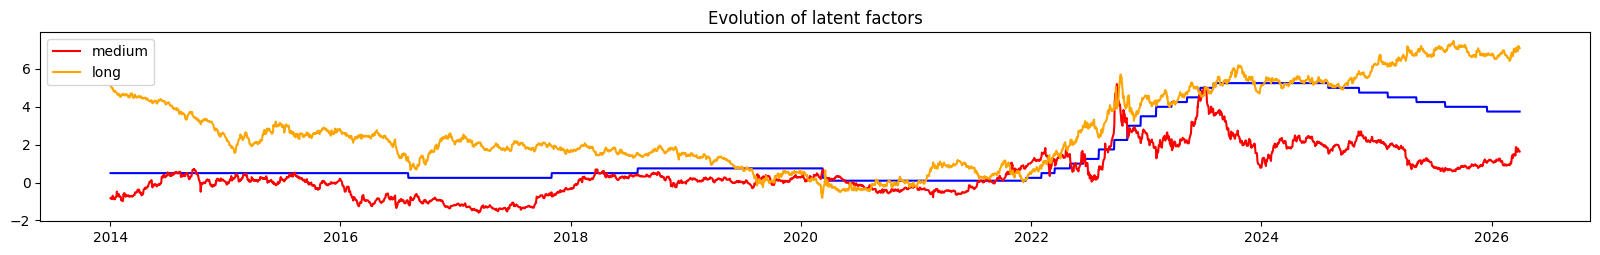

In [ ]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2022)

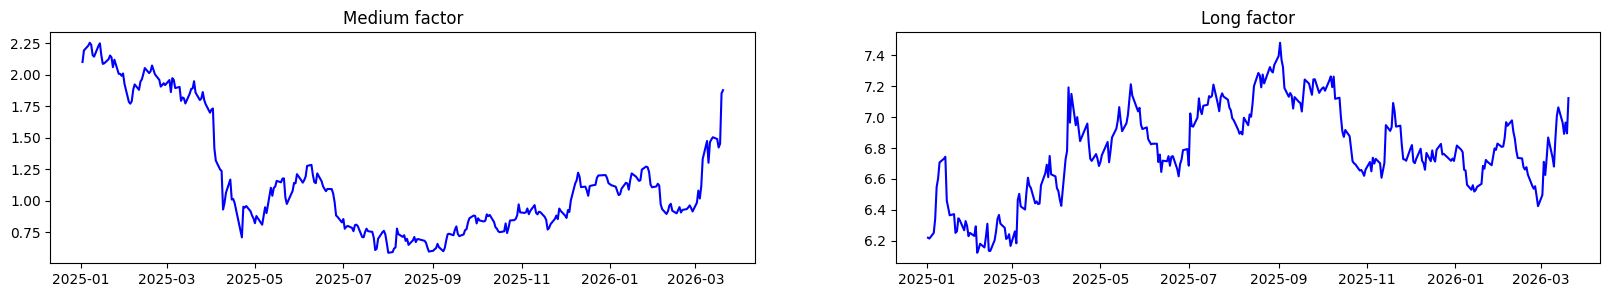

In [ ]:
limits = ('2025-01-01', '2026-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2022, limits = limits)

In [ ]:
calParams_2022 = dict(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'],
                  sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

fittedPricer_2022 = PricerClass(**calParams_2022)
fittedTs_full_2022 = [fittedPricer_2022.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2022.iloc[i].values)) for i in range(len(lf_full_2022))]
fittedTs_full_df_2022 = pd.DataFrame(fittedTs_full_2022, columns = MATURITIES, index = pd.to_datetime(estFactorsDf_full_2022.index))
fittedTs_full_df_2022.index = pd.to_datetime(fittedTs_full_df_2022.index)
fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]]

In [ ]:
fittingErrors_2022 = fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]].dropna(axis= 1)
fittingErrors_byYear_2022 = (fittingErrors_2022.groupby(fittingErrors_2022.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

85.231


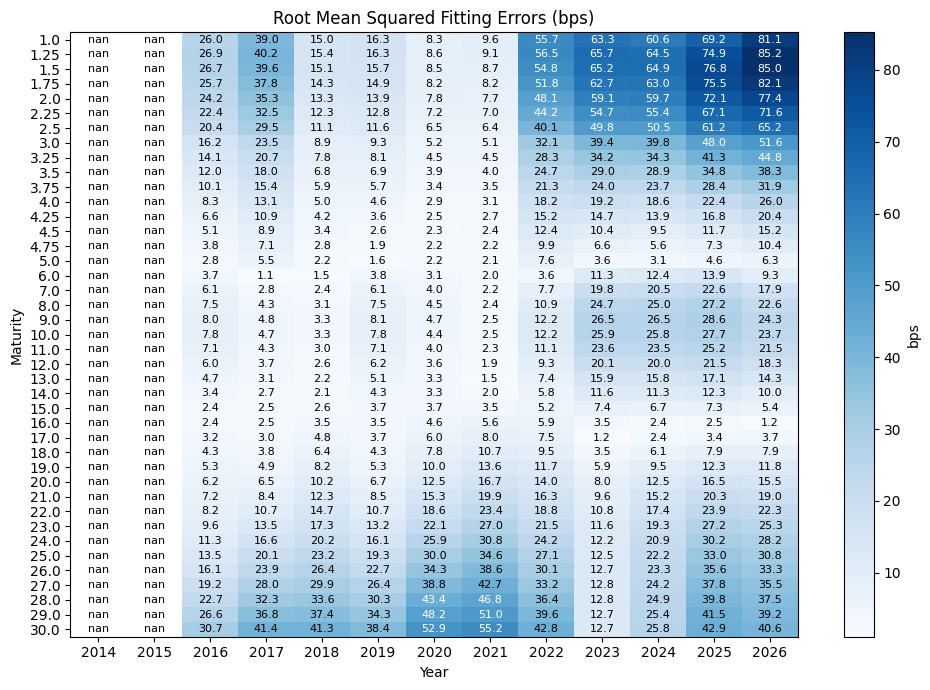

In [ ]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2022, figsize = (10, 7))

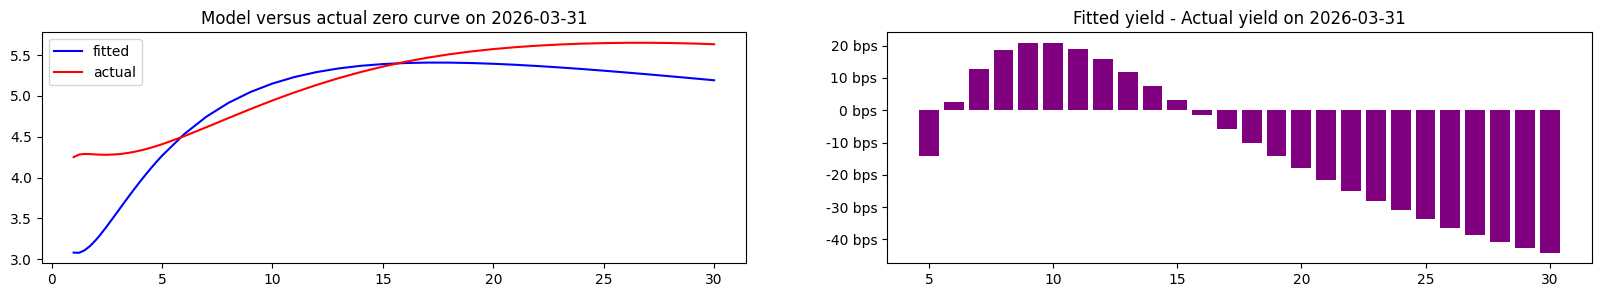

In [ ]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2022[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns] + ['short']],
                    tenorsAbove=4)

### 2. Calibration from 2016 to 2024, on yields up to 35 yrs

In [25]:
sampleDates = ('2016-01-01', '2024-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 31)]

print('Using maturities from', MATURITIES[0], 'to', MATURITIES[-1], 'years.')

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

Using maturities from 1.0 to 30 years.


In [26]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2024.maturities[0], 'to', cal_2024.maturities[-1], 'years.')
best_alpha_2024 =cal_2024.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2024 = cal_2024.calibrateSigma(alpha_r = best_alpha_2024['alpha_r'], 
                                alpha_m = best_alpha_2024['alpha_m'], 
                                alpha_l = best_alpha_2024['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2024 = cal_2024.calibrateMu(alpha_r = best_alpha_2024['alpha_r'], 
                          alpha_m = best_alpha_2024['alpha_m'], 
                          alpha_l = best_alpha_2024['alpha_l'], 
                          sigma_m = best_sigma_2024['sigma_m'], 
                          sigma_l = best_sigma_2024['sigma_l'], 
                          rho = best_sigma_2024['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2016-01-04 and 2023-12-29
Using maturities from 1.0 to 30 years.
alpha_r: 2.030000000000001, alpha_m: 0.4019179114987534,               alpha_l: 0.015553634578342208, loss: 0.05479934980437952,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.084438917243474, sigma_l: 0.07462919813425709, rho: 0.21360838855417247, loss: 2.5662727243848906e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 9.479721172802451, loss: 1894.968289215146, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


We fit on yields from 1 to 5 years in breaks of 6 months and on yields above 5 years in breaks of 1 year. I also tried with the whole term structure in breaks of 6 months but the fit was terrible. 

#### 2.1 Inspecting calibration fit

In [38]:
empiricalAlpha = np.vstack([x for x in cal_2024.regression()])
modelImpliedAlpha = np.vstack([[cal_2024.alphaComparison(tau = x, alpha_r = best_alpha_2024['alpha_r'], 
                                                         alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'])] for x in cal_2024.maturities])

comparisonDf_2y = pd.DataFrame({'spot maturity': cal_2024.maturities, 'empirical': empiricalAlpha[:, 0], 'model implied': modelImpliedAlpha[:, 0]}).set_index('spot maturity')
comparisonDf_10y = pd.DataFrame({'spot maturity': cal_2024.maturities, 'empirical': empiricalAlpha[:, 1], 'model implied': modelImpliedAlpha[:, 1]}).set_index('spot maturity')

fonts already added so will not add again


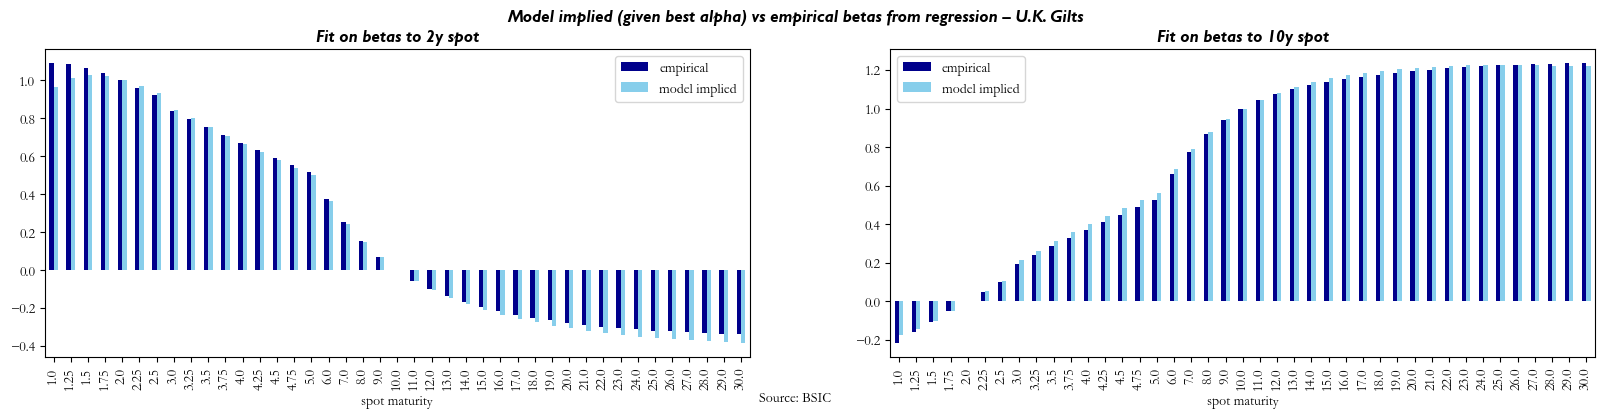

In [40]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20,4))
comparisonDf_2y.plot(kind = 'bar', ax=ax[0], title = f'Fit on betas to {int(cal_2024.fairly_priced[0])}y spot', color= ['darkblue', 'skyblue'])
comparisonDf_10y.plot(kind = 'bar', ax=ax[1], title = f'Fit on betas to {int(cal_2024.fairly_priced[1])}y spot', color= ['darkblue', 'skyblue'])
fig.suptitle("Model implied (given best alpha) vs empirical betas from regression – U.K. Gilts")
bsic.apply_bsic_style(fig, ax)
plt.savefig('plots/gilt/empiricalVsModelBetas.png', dpi = 300)
bsic.export_figure(fig, 'plots/gilt/empiricalVsModelBetas')

In [10]:
empiricalSigma = np.array([cal_2024.empiricalVariance(tau = x, alpha_r=best_alpha_2024['alpha_r']) for x in cal_2024.maturities])
modelImpliedSigma = np.array([cal_2024.modelImpliedVariance(
    tau = x, alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
    sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho']) for x in cal_2024.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2024.maturities, 
                                   'empirical': empiricalSigma, 
                                   'model implied': modelImpliedSigma}).set_index('spot maturity')

<Axes: title={'center': 'Fit on variances of each yield'}, xlabel='spot maturity'>

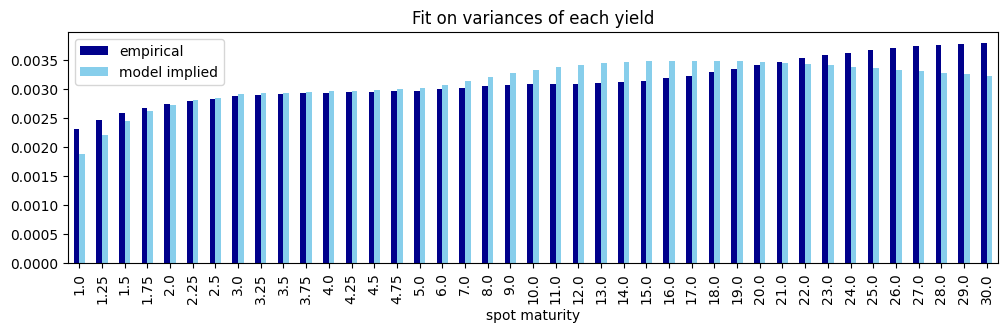

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,3))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, title = f'Fit on variances of each yield', color= ['darkblue', 'skyblue'])

##### 2.1.2 What if we calibrated sigma with Cholesky factorization?

In [27]:
best_sigma_chol_2024 = cal_2024.calibrateSigmaChol(alpha_r = best_alpha_2024['alpha_r'], 
                                alpha_m = best_alpha_2024['alpha_m'], 
                                alpha_l = best_alpha_2024['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_chol_2024 = cal_2024.calibrateMu(alpha_r = best_alpha_2024['alpha_r'], 
                          alpha_m = best_alpha_2024['alpha_m'], 
                          alpha_l = best_alpha_2024['alpha_l'], 
                          sigma_m = best_sigma_chol_2024['sigma_m'], 
                          sigma_l = best_sigma_chol_2024['sigma_l'], 
                          rho = best_sigma_chol_2024['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

sigma_m: 0.08422558654644494, sigma_l: 0.07193323871198021, rho: 0.2726848965534737, loss: 6.625794304159852e-05, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 9.313468265113016, loss: 1941.8123212629578, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


fonts already added so will not add again


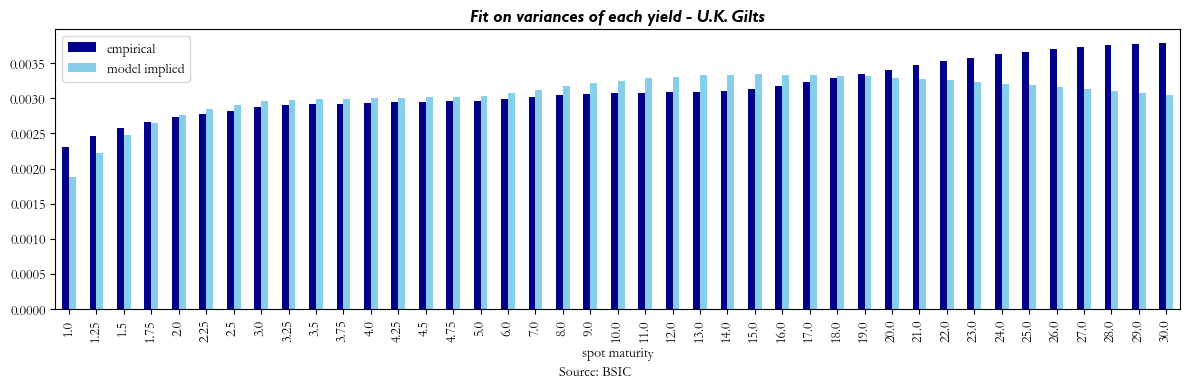

In [35]:
empiricalSigma = np.array([cal_2024.empiricalVariance(tau = x, alpha_r=best_alpha_2024['alpha_r']) for x in cal_2024.maturities])
modelImpliedSigma = np.array([cal_2024.modelImpliedVariance(tau = x, alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
                         sigma_m = best_sigma_chol_2024['sigma_m'], sigma_l = best_sigma_chol_2024['sigma_l'], rho = best_sigma_chol_2024['rho']) for x in cal_2024.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2024.maturities, 'empirical': empiricalSigma, 'model implied': modelImpliedSigma}).set_index('spot maturity')

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,4))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, 
                        title = f'Fit on variances of each yield - U.K. Gilts', 
                        color= ['darkblue', 'skyblue'])

plt.tight_layout(rect = [0, 0, 1, 0.95])
bsic.apply_bsic_style(fig, ax)
plt.savefig('plots/gilt/empiricalVsModelVariances_chol.png', dpi = 300)
bsic.export_figure(fig, 'plots/gilt/empiricalVsModelVariances_chol')

In [14]:
print('Sigma with chol', best_sigma_chol_2024['sigma_m'], best_sigma_chol_2024['sigma_l'], best_sigma_chol_2024['rho'], 'mu=', best_mu_chol_2024)
print('Sigma with direct', best_sigma_2024['sigma_m'], best_sigma_2024['sigma_l'], best_sigma_2024['rho'], 'mu=', best_mu_2024)

Sigma with chol 0.08422558654644494 0.07193323871198021 0.2726848965534737 mu= {'mu': 9.313468265113016, 'loss': 1941.8123212629578, 'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'}
Sigma with direct 0.084438917243474 0.07462919813425709 0.21360838855417247 mu= {'mu': 9.479721172802451, 'loss': 1894.968289215146, 'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'}


#### 2.2. Inspecting Extrapolated Factors

In [67]:
termStructurePath = zeroCouponYields.copy()[0:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [69]:
chol = True

if not chol:
    lf_full_2024 = cal_2024.extractLatentFactors_fwd(alpha_r = best_alpha_2024['alpha_r'], 
                                                    alpha_m = best_alpha_2024['alpha_m'], 
                                                    alpha_l = best_alpha_2024['alpha_l'], 
                                                    sigma_m = best_sigma_2024['sigma_m'], 
                                                    sigma_l = best_sigma_2024['sigma_l'], 
                                                    rho = best_sigma_2024['rho'], 
                                                    mu = best_mu_2024['mu'])
else:
    lf_full_2024 = cal_2024.extractLatentFactors_fwd(alpha_r = best_alpha_2024['alpha_r'], 
                                                    alpha_m = best_alpha_2024['alpha_m'], 
                                                    alpha_l = best_alpha_2024['alpha_l'], 
                                                    sigma_m = best_sigma_chol_2024['sigma_m'], 
                                                    sigma_l = best_sigma_chol_2024['sigma_l'], 
                                                    rho = best_sigma_chol_2024['rho'], 
                                                    mu = best_mu_chol_2024['mu'])
    
estFactorsDf_full_2024 = pd.DataFrame(lf_full_2024, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full_2024['short'] = termStructurePath['short']
estFactorsDf_full_2024 = estFactorsDf_full_2024[['short', 'medium', 'long']]
estFactorsDf_full_2024.iloc[-1]

estFactorsDf_full_2024['2y1y'] = (3 * zeroCouponYields[3] - 2 * zeroCouponYields[1])/1
estFactorsDf_full_2024['10y1y'] = (11 * zeroCouponYields[11] - 10 * zeroCouponYields[10])/1

fonts already added so will not add again


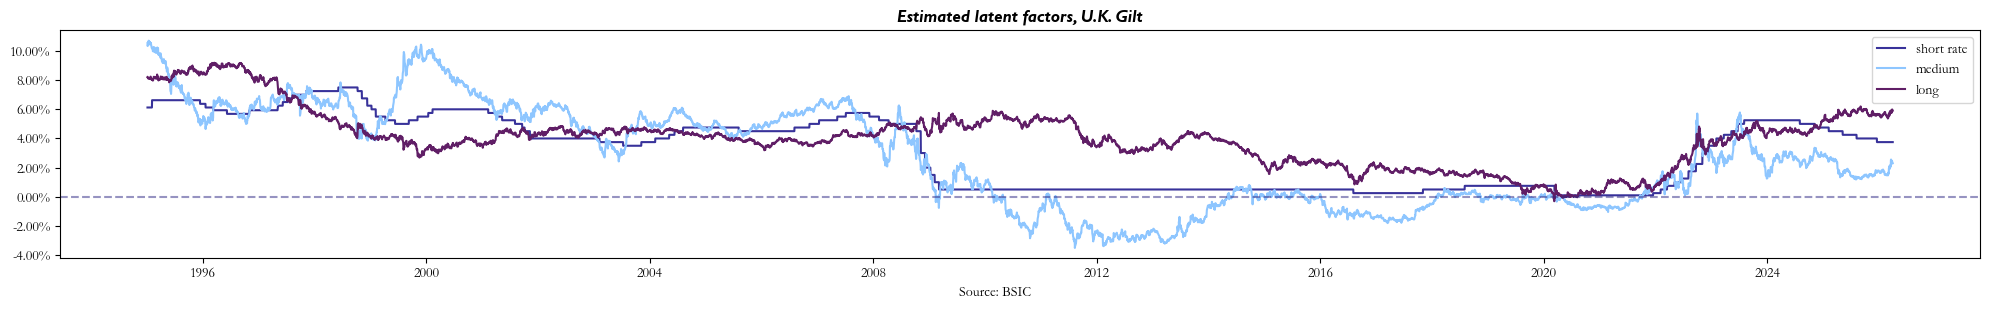

In [71]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2024,
                title = 'Estimated latent factors, U.K. Gilt', export = True, exportName = 'plots/gilt/latentFactors')

What happened to the factors during the fiscal episodes of 2022?

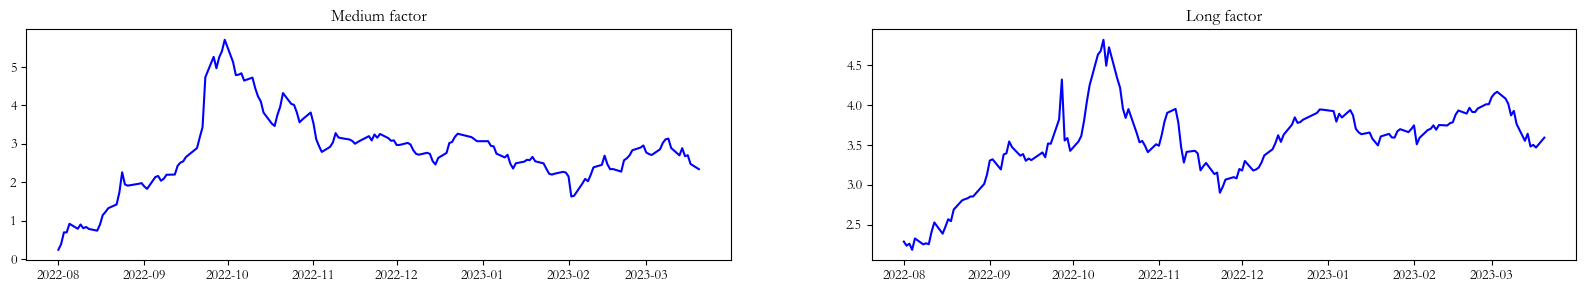

In [ ]:
limits = ('2022-08-01', '2023-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2024, limits = limits)

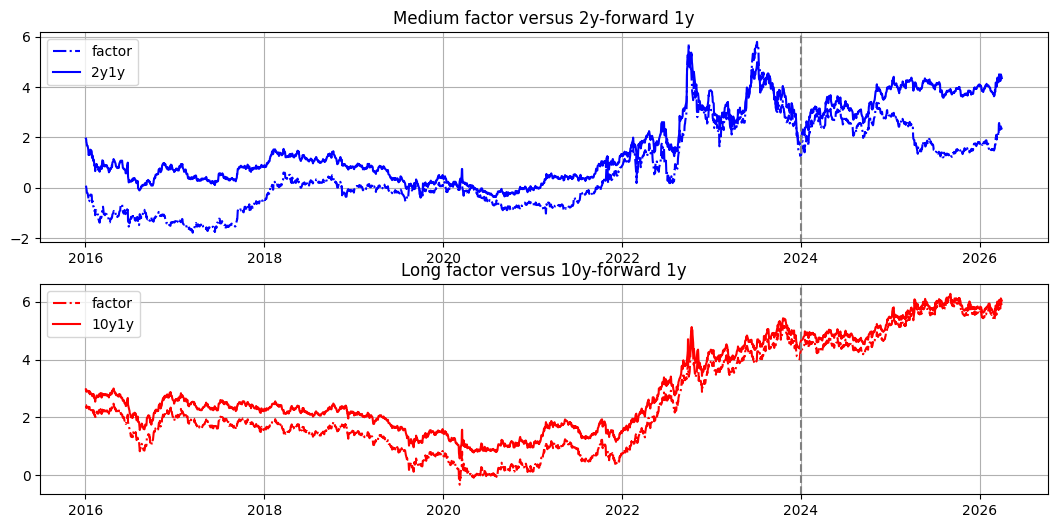

In [ ]:
factorsForwardsPlot(estFactorsDf_full=estFactorsDf_full_2024, sampleDates=sampleDates, figsize=(13,6))

In [72]:
calParams_2024 = dict(alpha_r = best_alpha_2024['alpha_r'], 
                      alpha_m = best_alpha_2024['alpha_m'], 
                      alpha_l = best_alpha_2024['alpha_l'],
                      sigma_m = best_sigma_2024['sigma_m'], 
                      sigma_l = best_sigma_2024['sigma_l'], 
                      rho = best_sigma_2024['rho'], 
                      mu = best_mu_2024['mu'])

if chol:
    calParams_2024['sigma_m'] = best_sigma_chol_2024['sigma_m']
    calParams_2024['sigma_l'] = best_sigma_chol_2024['sigma_l']
    calParams_2024['rho'] = best_sigma_chol_2024['rho']
    calParams_2024['mu'] = best_mu_chol_2024['mu']

fittedPricer_2024 = PricerClass(**calParams_2024)
fittedTs_full_2024 = [fittedPricer_2024.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2024.iloc[i].values)) for i in range(len(lf_full_2024))]
fittedTs_full_df_2024 = pd.DataFrame(fittedTs_full_2024, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df_2024.index = pd.to_datetime(fittedTs_full_df_2024.index)
fittedTs_full_df_2024 = fittedTs_full_df_2024[sampleDates[0]:]
fittedTs_full_df_2024 = fittedTs_full_df_2024[[col for col in fittedTs_full_df_2024.columns if col in termStructurePath.columns]]

fittingErrors_2024 = (fittedTs_full_df_2024 - termStructurePath[MATURITIES]).dropna()
fittingErrors_byYear_2024 = (fittingErrors_2024.groupby(fittingErrors_2024.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

adding fonts to font manager
base dir:  /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mpl_bsic
fonts dir:  /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mpl_bsic/fonts


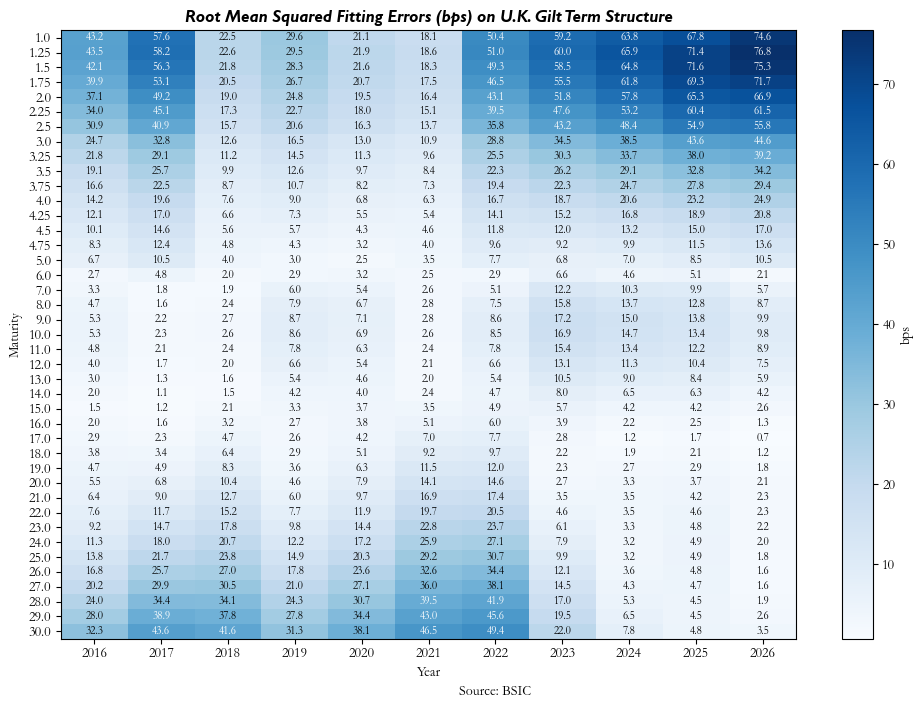

In [18]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2024, figsize = (10, 7),
                     title = 'Root Mean Squared Fitting Errors (bps) on U.K. Gilt Term Structure',
                     export=True, exportName = 'plots/gilt/fittingErrorsHeatmap')

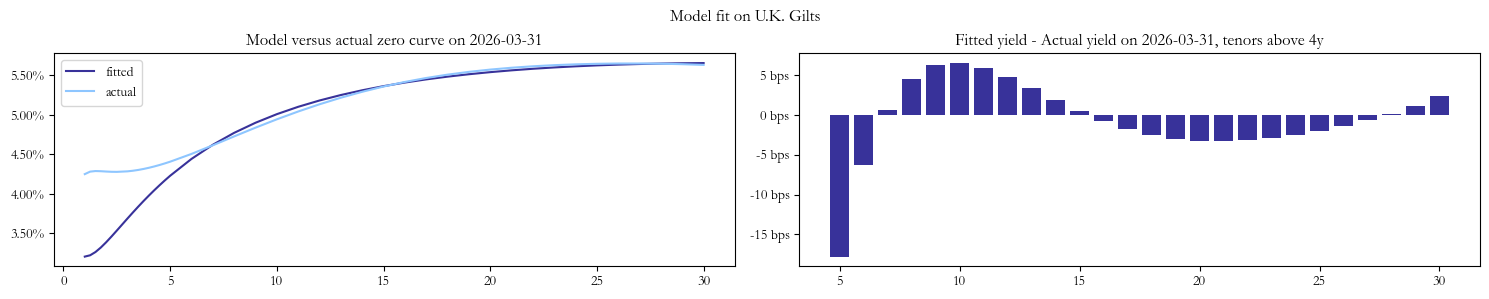

In [ ]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2024[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns] + ['short']],
                    tenorsAbove=4,
                    title = 'Model fit on U.K. Gilts', figsize = (15,3), 
                    export=True, exportName = 'plots/gilt/actualVsFittedCurve')

<Axes: >

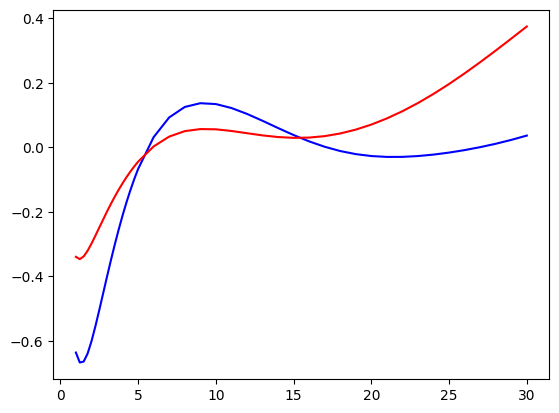

In [19]:
fittingErrors_2024['2024-01-01':].mean().plot(color = 'blue', label = 'oos')
fittingErrors_2024[:'2024-01-01'].mean().plot(color = 'red', label = 'is')

### 3. Models backtest (2016-2024 calibration, 1y-30y)

In [99]:
screen = tradeScreener(modelData = fittedTs_full_df_2024,
                       actualData = zeroCouponYields,
                       maturitySet = [x for x in cal_2024.maturities if int(x) > 0],
                       modelData_fwd= fittedTs_full_df_2024,         # PLEASE FEED FORWARDS IF YOU WANT TO SCREEN FOR FORWARDS
                       actualData_fwd= fittedTs_full_df_2024,
                       maturitySet_fwd=None)

In [100]:
outrightScreen = screen.outrightScreener(shortW = 5, longW = 40, zScoreW = 14)
outrightScreen = outrightScreen.reset_index().loc[~outrightScreen.reset_index()['index'].apply(
    lambda x: str(x).__contains__('.25') or str(x).__contains__('.75'))].set_index('index')

slopeScreen = screen.slopeScreener(shortW = 5, longW = 40, zScoreW = 14)
slopeScreen = slopeScreen.reset_index().loc[~slopeScreen.reset_index()['index'].apply(
    lambda x: x.__contains__('.25') or x.__contains__('.75'))].set_index('index')

flyScreen = screen.flyScreener(shortW = 5, longW = 40, zScoreW = 14)
flyScreen = flyScreen.reset_index().loc[~flyScreen.reset_index()['index'].apply(
    lambda x: x.__contains__('.25') or x.__contains__('.75'))].set_index('index')
# fwdScreen = screen.outrightScreener_fwd()

slopeDict = screen.buildSlopes()
flyDict = screen.buildFlies()

backtestParams = dict(
    startDt='2024-01-01', 
    endDt=None,
    shortW = 5, 
    longW = 40, 
    standardW=14,
    numberSigma = 2,
    stopLossSigma = 1,
    stopLossAboveEntry = True
)

allOutrightBacktest = screen.allOutrightBacktest(**backtestParams)
allSlopeBacktest = screen.allSlopesBacktest(**backtestParams, minSpacing = 4)
allFliesBacktest = screen.allFliesBacktest(**backtestParams, minSpacing = 4)

allOutrightBacktest = allOutrightBacktest.loc[allOutrightBacktest['maturity'].apply(lambda x: not str(x).__contains__('.25') 
                                                                                    and not str(x).__contains__('.75'))]
allSlopeBacktest = allSlopeBacktest.loc[allSlopeBacktest['slope'].apply(lambda x: not str(x).__contains__('.25') 
                                                                           and not str(x).__contains__('.75'))]
allFliesBacktest = allFliesBacktest.loc[allFliesBacktest['fly'].apply(lambda x: not str(x).__contains__('.25') 
                                                                           and not str(x).__contains__('.75'))]

topSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('slope')
botSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').head(10).set_index('slope')
topFlies = allFliesBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('fly')
botFlies = allFliesBacktest.round(3).sort_values(by='hitrate').head(10).set_index('fly')

In [101]:
overallHitRate = sum([(bt['hitrate'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
overallSkew = sum([(bt['skew'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
overallStop = sum([(bt['stop'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
print(f'{"Strategy": <20} {"Tot Hit Rate": <20} {"Tot Skew": <20} {"Stop Triggered": <20} {"Tot Trades": <20}')
print('----'*25)
for backtest, name in zip([allOutrightBacktest, allSlopeBacktest, allFliesBacktest], ['Outrights', 'Slopes', 'Flies']):
    hr = (backtest['hitrate'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    sk = (backtest['skew'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    stop = (backtest['stop'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    n = backtest['n_trades'].sum()
    
    print(f'{f'{name}:': <20} {hr.round(4): <20}  {sk.round(4): <20} {stop.round(4): <20} {n: <20}')
print('----'*25)
print(f'{"Overall:": <20} {overallHitRate.round(4): <20}  {overallSkew.round(4): <20} {overallStop.round(4): <20} {sum([bt["n_trades"].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]]): <20}')

    


Strategy             Tot Hit Rate         Tot Skew             Stop Triggered       Tot Trades          
----------------------------------------------------------------------------------------------------
Outrights:           0.6458                2.3659               0.3542               271                 
Slopes:              0.3691                1.6414               0.6309               3853                
Flies:               0.5178                1.925                0.4822               900                 
----------------------------------------------------------------------------------------------------
Overall:             0.4106                1.7313               0.5894               5024                


In [43]:
backtests = {'Outrights': allOutrightBacktest,'Slopes': allSlopeBacktest,'Flies': allFliesBacktest}

rows = []

for name, bt in backtests.items():
    total_trades = bt['n_trades'].sum()
    hr = (bt['hitrate'] * bt['n_trades']).sum() / total_trades
    sk = (bt['skew'] * bt['n_trades']).sum() / total_trades
    stop = (bt['stop'] * bt['n_trades']).sum() / total_trades
    
    rows.append({
        'Strategy': name,
        'Hit Rate': round(hr, 4),
        'Skew': round(sk, 4),
        'N. Trades': total_trades
    })

df = pd.DataFrame(rows)

# overall row
total_trades_all = sum(bt['n_trades'].sum() for bt in backtests.values())

overall = {
    'Strategy': 'Overall',
    'Hit Rate': round(sum((bt['hitrate'] * bt['n_trades']).sum() for bt in backtests.values()) / total_trades_all, 4),
    'Skew': round(sum((bt['skew'] * bt['n_trades']).sum() for bt in backtests.values()) / total_trades_all, 4),
    'N. Trades': total_trades_all
}

df = pd.concat([df, pd.DataFrame([overall])], ignore_index=True)
bsic.df_to_excel(df, 'exports/gilt/gilt_overallStats.xlsx')

closing wb


fonts already added so will not add again


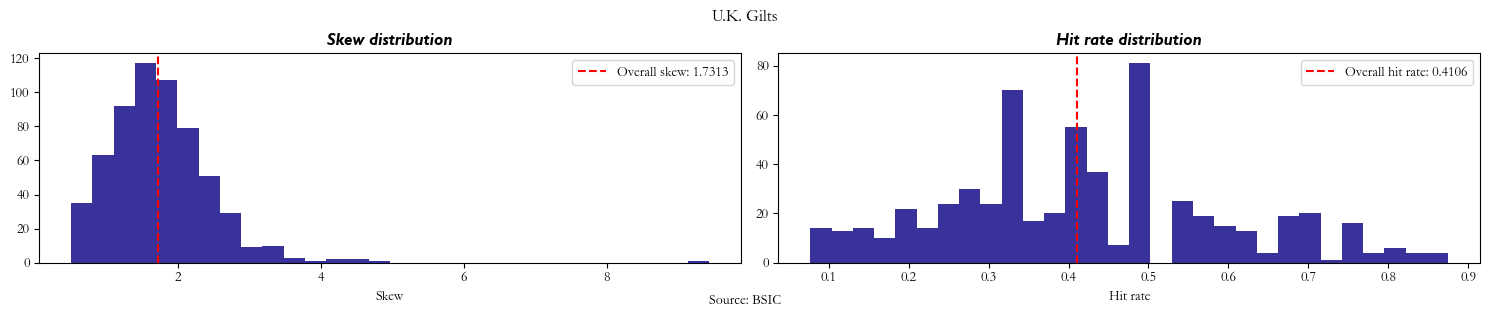

In [44]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 3))
bsic.apply_bsic_style(fig, ax)
ax[0].hist(pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()])['skew'], bins = 30);
ax[0].set_title('Skew distribution')
ax[0].set_xlabel('Skew')
ax[0].axvline(overallSkew, color = 'red', linestyle = '--', label = f'Overall skew: {overallSkew.round(4)}');
ax[0].legend()
ax[1].hist(pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()])['hitrate'], bins = 30);
ax[1].set_title('Hit rate distribution')
ax[1].set_xlabel('Hit rate')
ax[1].axvline(overallHitRate, color = 'red', linestyle = '--', label = f'Overall hit rate: {overallHitRate.round(4)}')
ax[1].legend();
fig.suptitle('U.K. Gilts')
plt.tight_layout(rect = [0, -0.05, 1, 1.05])
plt.savefig('plots/gilt/overallBacktestResults.png', dpi = 300)
bsic.export_figure(fig, 'plots/gilt/overallBacktestResults')

In [107]:
def bucket(x):
    if x < 5:
        return 'frontend'
    elif x >= 5 and x <= 15:
        return 'mid'
    elif x > 15 and x < 24:
        return 'long'
    else:
        return 'ultralong'
    
def weighted_mean(group, value_col, weight_col):
    w = group[weight_col]
    x = group[value_col]
    return (x * w).sum() / w.sum() if w.sum() != 0 else np.nan

allSlopeBacktest['leg1bucket'] = allSlopeBacktest['slope'].apply(lambda x: x.split('s')[0]).apply(lambda x: bucket(float(x)))
allSlopeBacktest['leg2bucket'] = allSlopeBacktest['slope'].apply(lambda x: x.split('s')[1]).apply(lambda x: bucket(float(x)))

order = ['frontend', 'mid', 'long', 'ultralong']
hitRateRecap = allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['hitrate'].mean().unstack().round(4)
hitRateRecap = hitRateRecap.reindex(index=order, columns=order)

skewRecap = allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['skew'].mean().unstack().round(4)
skewRecap = skewRecap.reindex(index=order, columns=order)

hitRateRecap = (allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket']).apply(lambda g: weighted_mean(g, 'hitrate', 'n_trades')).unstack().round(4).reindex(index=order, columns=order))
skewRecap = (allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['skew'].mean().unstack().round(4).reindex(index=order, columns=order))
avgTradesRecap = (allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['n_trades'].mean().unstack().round(1).reindex(index=order, columns=order))

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_3717/2048614537.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hitRateRecap = (allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket']).apply(lambda g: weighted_mean(g, 'hitrate', 'n_trades')).unstack().round(4).reindex(index=order, columns=order))


In [46]:
hitRateRecap

leg2bucket,frontend,mid,long,ultralong
leg1bucket,,,,
frontend,NaN,0.5142,0.3982,0.3318
mid,NaN,0.4534,0.4162,0.3342
long,NaN,NaN,0.3391,0.1941
ultralong,NaN,NaN,NaN,0.1509


In [47]:
skewRecap

leg2bucket,frontend,mid,long,ultralong
leg1bucket,,,,
frontend,NaN,1.86431,1.671078,1.556238
mid,NaN,1.499906,1.393974,1.544254
long,NaN,NaN,1.775337,1.957615
ultralong,NaN,NaN,NaN,2.137375


In [ ]:
allOutrightBacktest['bucket'] = allOutrightBacktest['maturity'].apply(lambda x: bucket(float(x)))
outrightRecap = pd.DataFrame({'Average hit rate': allOutrightBacktest.groupby('bucket')['hitrate'].mean().round(4).values,
              'Average skew': allOutrightBacktest.groupby('bucket')['skew'].mean().round(4).values,
              'Average N. Trades': allOutrightBacktest.groupby('bucket')['n_trades'].mean().round(1).values
              }, 
              index = order)

bsic.df_to_excel(outrightRecap, 'exports/gilt/gilt_outrightBacktestRecap.xlsx')

closing wb


In [48]:
exportName = 'exports/gilt/gilt_curveTradesRecap'

hitRateRecap = hitRateRecap.replace(np.nan, "")
skewRecap = skewRecap.replace(np.nan, "")
avgTradesRecap = avgTradesRecap.replace(np.nan, "")

hitRateRecap.index.name = 'Leg 1 (rows), Leg 2 (columns)'
skewRecap.index.name = 'Leg 1 (rows), Leg 2 (columns)'
avgTradesRecap.index.name = 'Leg 1 (rows), Leg 2 (columns)'

bsic.df_to_excel(hitRateRecap, f"{exportName}_hitRate.xlsx")
bsic.df_to_excel(skewRecap, f"{exportName}_skew.xlsx")
bsic.df_to_excel(avgTradesRecap, f"{exportName}_avgTrades.xlsx")

closing wb
closing wb
closing wb


/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/451282504.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  skewRecap = skewRecap.replace(np.nan, "")


In [49]:
def display_recap(d):
    out = pd.concat(d, axis=1)
    out.columns = pd.MultiIndex.from_tuples([(b2, l3) for b2 in order for l3 in order], names=['leg2', 'leg3'])
    return out

allFliesBacktest['leg1bucket'] = allFliesBacktest['fly'].apply(lambda x: bucket(int(float(x.split('s')[0]))))
allFliesBacktest['leg2bucket'] = allFliesBacktest['fly'].apply(lambda x: bucket(int(float(x.split('s')[1]))))
allFliesBacktest['leg3bucket'] = allFliesBacktest['fly'].apply(lambda x: bucket(int(float(x.split('s')[2]))))

hitRateRecap_fly, skewRecap_fly, tradesRecap_fly = {}, {}, {}

for b2 in order:
    sub = allFliesBacktest[allFliesBacktest['leg2bucket'] == b2]

    hitRateRecap_fly[b2] = (
        sub.groupby(['leg1bucket', 'leg3bucket'])
           .apply(lambda g: weighted_mean(g, 'hitrate', 'n_trades'))
           .unstack()
           .round(4)
           .reindex(index=order, columns=order)
    )

    skewRecap_fly[b2] = (
        sub.groupby(['leg1bucket', 'leg3bucket'])['skew']
           .mean()
           .unstack()
           .round(4)
           .reindex(index=order, columns=order)
    )

    tradesRecap_fly[b2] = (
        sub.groupby(['leg1bucket', 'leg3bucket'])['n_trades']
           .mean()
           .unstack()
           .round(1)   # usually nicer without too many decimals
           .reindex(index=order, columns=order)
    )

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/1409216342.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_mean(g, 'hitrate', 'n_trades'))
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/1409216342.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_mean(g, 'hitrate', 'n_trades'))
/var/folders/6s/ljt_tdhn2332n40p605w9d

In [50]:
def to_long(d, val_name):
    df = display_recap(d).copy()
    return (
        df.stack([0, 1])
          .reset_index()
          .rename(columns={
              'level_0': 'leg1',
              'level_1': 'leg2',
              'level_2': 'leg3',
              0: val_name
          })
    )

skew_long   = to_long(skewRecap_fly,   'skew')
hit_long    = to_long(hitRateRecap_fly,'hitrate')
trades_long = to_long(tradesRecap_fly, 'n_trades')

# merge row-wise
out = (
    skew_long
    .merge(hit_long,   on=['leg1bucket','leg2','leg3'], how='outer')
    .merge(trades_long,on=['leg1bucket','leg2','leg3'], how='outer')
)

out.columns = ['Leg 1 bucket', 'Leg 2 bucket', 'Leg 3 bucket', 'Skew', 'Hit Rate', 'N. Trades']
out = out.dropna().reset_index(drop=True)
out.index = [""] * len(out)

bsic.df_to_excel(out, 'exports/gilt/gilt_flyTradesRecap.xlsx')

closing wb


/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/4087761640.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack([0, 1])
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/4087761640.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack([0, 1])
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/4087761640.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt 

In [51]:
out

,Leg 1 bucket,Leg 2 bucket,Leg 3 bucket,Skew,Hit Rate,N. Trades
,frontend,long,ultralong,2.100727,0.5000,7.5
,frontend,mid,long,1.663142,0.6250,8.0
,frontend,mid,mid,2.280699,0.6092,7.2
,frontend,mid,ultralong,2.09128,0.5824,9.1
,long,long,ultralong,1.41963,0.4430,7.9
,long,ultralong,ultralong,1.859338,0.4643,9.3
,mid,long,long,2.136376,0.5870,4.6
,mid,long,ultralong,1.809209,0.3400,5.6
,mid,mid,long,2.34006,0.6056,6.5
,mid,mid,mid,1.309858,0.7083,6.0


/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_5668/601792766.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleanDf = pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()]).fillna(0)


ValueError: alpha must be between 0 and 1, inclusive, but min is 0.2, max is 1.0000000000000002

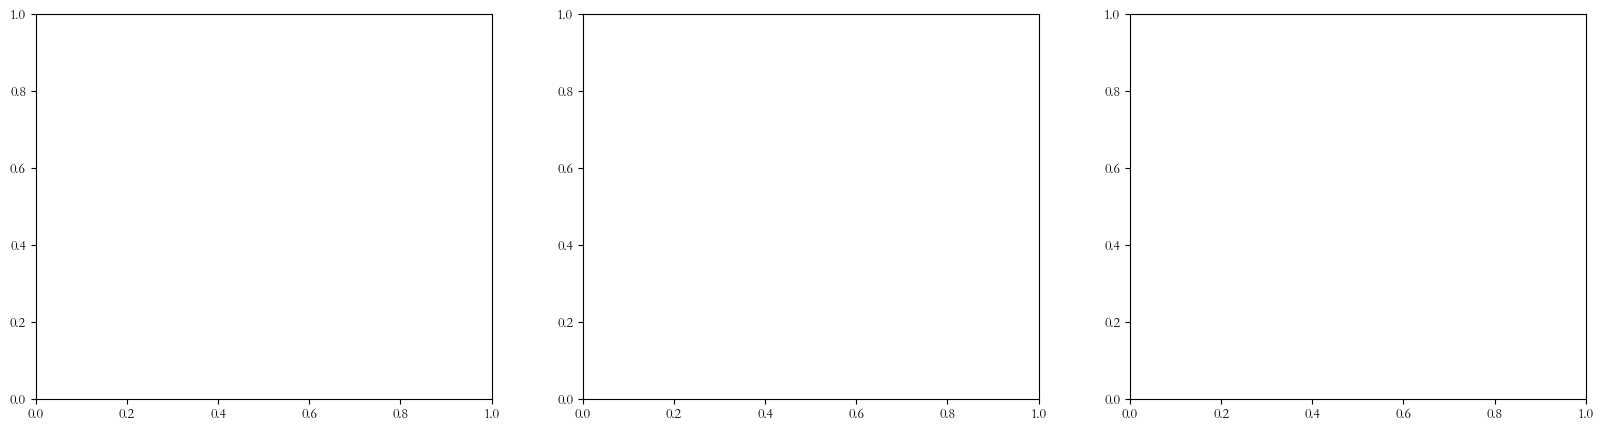

In [52]:
cleanDf = pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()]).fillna(0)
cleanDf['trade_type'] = np.select([cleanDf['fly'] != 0, cleanDf['slope'] != 0],['butterfly','slope'],default='outright')

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 5))
for i, trade_type in enumerate(['outright', 'slope', 'butterfly']):
    subset = cleanDf[cleanDf['trade_type'] == trade_type]
    n = subset['n_trades']
    alpha = 0.2 + 0.8 * (n - n.min()) / (n.max() - n.min())
    subset = cleanDf[cleanDf['trade_type'] == trade_type]
    ax[i].scatter(subset['hitrate'].apply(lambda x: (1 - x)/x), subset['skew'], alpha = alpha)
    ax[i].axline((0, 0), (1,1), color = 'red', linestyle = '--')
    ax[i].set_title(f'{trade_type.capitalize()} trades')
    ax[i].set_xlabel('1 - Hit rate / Hit rate')
    ax[i].set_ylabel('Skew')
    

#### 3.1. General stats on top 10/worst 10 trades

In [102]:
display(Markdown("### Backtest of predictions on outright tenors\n\n" + 
    allOutrightBacktest.set_index('maturity').to_markdown(floatfmt=".3f")))

### Backtest of predictions on outright tenors

|   maturity |   hitrate |    skew |   avg days |   median days |   n_trades |   stop |
|-----------:|----------:|--------:|-----------:|--------------:|-----------:|-------:|
|      1.000 |     0.375 |   1.362 |      6.125 |         4.500 |      8.000 |  0.625 |
|      1.500 |     0.750 |   1.140 |      3.125 |         3.000 |      8.000 |  0.250 |
|      2.000 |     0.727 |   0.991 |      2.455 |         2.000 |     11.000 |  0.273 |
|      2.500 |     0.600 |   1.159 |      2.300 |         1.500 |     10.000 |  0.400 |
|      3.000 |     0.636 |   1.096 |      2.364 |         2.000 |     11.000 |  0.364 |
|      3.500 |     0.556 |   1.694 |      1.889 |         1.000 |      9.000 |  0.444 |
|      4.000 |     0.500 |   1.164 |      2.200 |         1.000 |     10.000 |  0.500 |
|      4.500 |     0.600 |   1.469 |      2.100 |         1.000 |     10.000 |  0.400 |
|      5.000 |     0.700 |   1.120 |      2.100 |         1.000 |     10.000 |  0.300 |
|      6.000 |     0.625 |   4.263 |      1.250 |         1.000 |      8.000 |  0.375 |
|      7.000 |     0.556 |   1.531 |      1.667 |         1.000 |      9.000 |  0.444 |
|      8.000 |     0.667 |   2.344 |      1.333 |         1.000 |      6.000 |  0.333 |
|      9.000 |     0.500 |   2.388 |      1.250 |         1.000 |      8.000 |  0.500 |
|     10.000 |     0.500 |   2.491 |      1.333 |         1.000 |      6.000 |  0.500 |
|     11.000 |     0.500 |   2.355 |      1.333 |         1.000 |      6.000 |  0.500 |
|     12.000 |     0.500 |   2.257 |      1.250 |         1.000 |      8.000 |  0.500 |
|     13.000 |     0.600 |   2.318 |      1.400 |         1.000 |      5.000 |  0.400 |
|     14.000 |     1.000 | nan     |      1.500 |         1.000 |      4.000 |  0.000 |
|     15.000 |     1.000 | nan     |      1.400 |         1.000 |      5.000 |  0.000 |
|     16.000 |     1.000 | nan     |      1.667 |         1.000 |      3.000 |  0.000 |
|     17.000 |     0.714 |   9.426 |      1.429 |         1.000 |      7.000 |  0.286 |
|     18.000 |     0.750 |   4.470 |      1.250 |         1.000 |      8.000 |  0.250 |
|     19.000 |     0.750 |   4.187 |      1.250 |         1.000 |      8.000 |  0.250 |
|     20.000 |     0.714 |   3.218 |      1.286 |         1.000 |      7.000 |  0.286 |
|     21.000 |     0.571 |   2.628 |      1.286 |         1.000 |      7.000 |  0.429 |
|     22.000 |     0.556 |   2.687 |      1.222 |         1.000 |      9.000 |  0.444 |
|     23.000 |     0.625 |   2.051 |      1.500 |         1.000 |      8.000 |  0.375 |
|     24.000 |     0.750 |   3.242 |      1.625 |         1.000 |      8.000 |  0.250 |
|     25.000 |     0.750 |   3.067 |      1.625 |         1.000 |      8.000 |  0.250 |
|     26.000 |     0.778 |   2.953 |      1.778 |         1.000 |      9.000 |  0.222 |
|     27.000 |     0.750 |   3.109 |      1.750 |         1.000 |      8.000 |  0.250 |
|     28.000 |     0.750 |   2.997 |      1.750 |         1.000 |      8.000 |  0.250 |
|     29.000 |     0.636 |   2.024 |      1.636 |         1.000 |     11.000 |  0.364 |
|     30.000 |     0.500 |   2.915 |      1.700 |         1.000 |     10.000 |  0.500 |

In [54]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Curve trades by hit rate</h2>{topSlopes.T.to_html()}</div>
  <div><h2>Worst 10 Curve trades by hit rate</h2>{botSlopes.T.to_html()}</div>
</div>
"""
display(HTML(html))

slope,1.5s8s,3.5s10s,2.0s20s,4.0s13s,6s16s,3.0s7s,7s14s,3.0s8s,3.0s9s,7s13s
hitrate,0.714,0.714,0.75,0.75,0.778,0.8,0.818,0.833,0.833,0.833
skew,2.371491,1.691584,1.581983,2.64365,1.57155,2.473433,1.593295,2.372554,1.945409,1.582668
avg days,11.143,4.286,4.75,3.875,2.0,4.4,2.364,4.667,4.0,2.167
median days,6.0,5.0,5.5,4.5,1.0,4.0,1.0,4.5,4.5,2.0
n_trades,7,7,4,8,9,5,11,6,6,6
stop,0.286,0.286,0.25,0.25,0.222,0.2,0.182,0.167,0.167,0.167
slope,2.5s29s,2.5s30s,11s16s,18s26s,19s26s,18s27s,20s25s,20s27s,17s27s,20s26s
hitrate,0.0,0.0,0.0,0.077,0.077,0.077,0.077,0.091,0.091,0.091
skew,<NA>,<NA>,<NA>,1.894154,1.851572,1.852586,1.850412,2.360305,1.838579,2.428475
avg days,5.833,6.8,5.667,6.769,6.769,6.769,6.769,9.091,7.182,9.364


In [55]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Fly trades by hit rate</h2>{topFlies.T.to_html()}</div>
  <div><h2>Worst 10 Fly trades by hit rate</h2>{botFlies.T.to_html()}</div>
</div>
"""
display(HTML(html))

fly,12s19s26s,6s10s14s,14s18s22s,13s19s25s,5s10s15s,8s12s16s,7s12s17s,4.0s11s18s,2.0s8s14s,4.0s8s12s
hitrate,0.8,0.8,0.8,0.8,0.833,0.857,0.857,0.857,0.875,1.0
skew,1.245336,1.103839,1.544098,1.150142,1.116359,0.984646,0.862214,1.1278,2.040379,NaN
avg days,7.2,6.0,10.0,5.6,5.833,4.286,3.571,5.714,7.75,12.75
median days,4.0,5.0,14.0,4.0,5.0,2.0,2.0,5.0,5.5,8.0
n_trades,5,5,5,5,6,7,7,7,8,4
stop,0.2,0.2,0.2,0.2,0.167,0.143,0.143,0.143,0.125,0.0
fly,13s20s27s,11s18s25s,1.0s11s21s,7s18s29s,8s18s28s,14s20s26s,13s21s29s,9s18s27s,11s20s29s,6s17s28s
hitrate,0.0,0.0,0.125,0.143,0.2,0.2,0.2,0.2,0.2,0.222
skew,<NA>,<NA>,1.873339,1.552349,1.309958,1.776545,1.690932,2.357719,1.878572,2.254839
avg days,7.5,8.5,3.5,5.143,6.4,10.2,9.2,6.2,5.4,2.667


#### 3.2. Attractive outright trades right now

Text(0.5, 1.0, 'Outright trade screener')

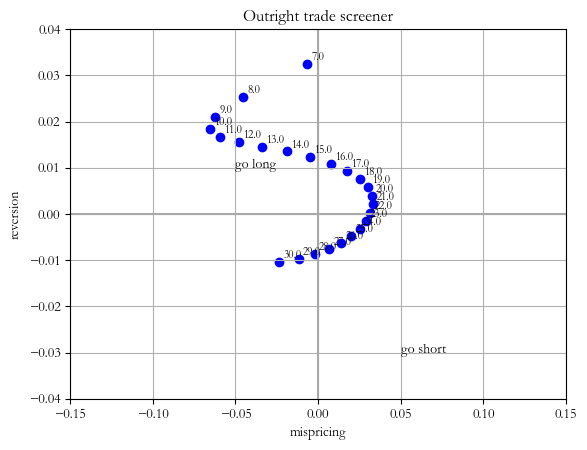

In [142]:
plt.axhline(y = 0, color = 'darkgrey')
plt.axvline(x = 0, color = 'darkgrey')
plt.scatter(outrightScreen['error'], outrightScreen['signal'], color = 'blue')
for i, txt in enumerate(outrightScreen.index):
    plt.annotate(txt,
                 (outrightScreen['error'].iloc[i], outrightScreen['signal'].iloc[i]),
                 xytext=(3,3),
                 textcoords='offset points',
                 fontsize=8)
plt.annotate(text = 'go short', xy = (0.05, - 0.03))
plt.annotate(text = 'go long', xy = (-0.05, + 0.01))
plt.xlim(-0.15, 0.15)
plt.ylim(-0.04, +0.04)
plt.xlabel('mispricing')
plt.ylabel('reversion')
plt.grid(True)
plt.title('Outright trade screener')

We generally trade stuff with zscore above 2. Is there anything around that value?

   entry_date  exit_date   side  entry_actual    target  stopPrice  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
12 2024-01-30 2024-01-31  SHORT      4.563584  4.574532   4.558526     4.485530    0.013495   0.023464      0.011635     0.010938 -2.164155 -0.193559   True    stop_loss -0.078054     1  False
13 2024-02-28 2024-02-29   LONG      4.653333  4.634762   4.661173     4.560456    0.032199   0.018789     -0.000019     0.002582  2.368656  0.658251  False  take_profit  0.092876     1   True
14 2025-03-26 2025-03-27  SHORT      5.304759  5.318233   5.298354     5.377306    0.002164   0.001420      0.000703    -0.001370 -2.103999 -2.220180  False  take_profit  0.072547     1   True
15 2025-06-25 2025-06-26   LONG      5.250625  5.231572   5.257998     5.264138    0.023737   0.034420     -0.004797    -0.000047  2.583862  4.032632   True    stop_loss -0.013514     1  False
16 2025-09-03 2025-09-04  SHORT    

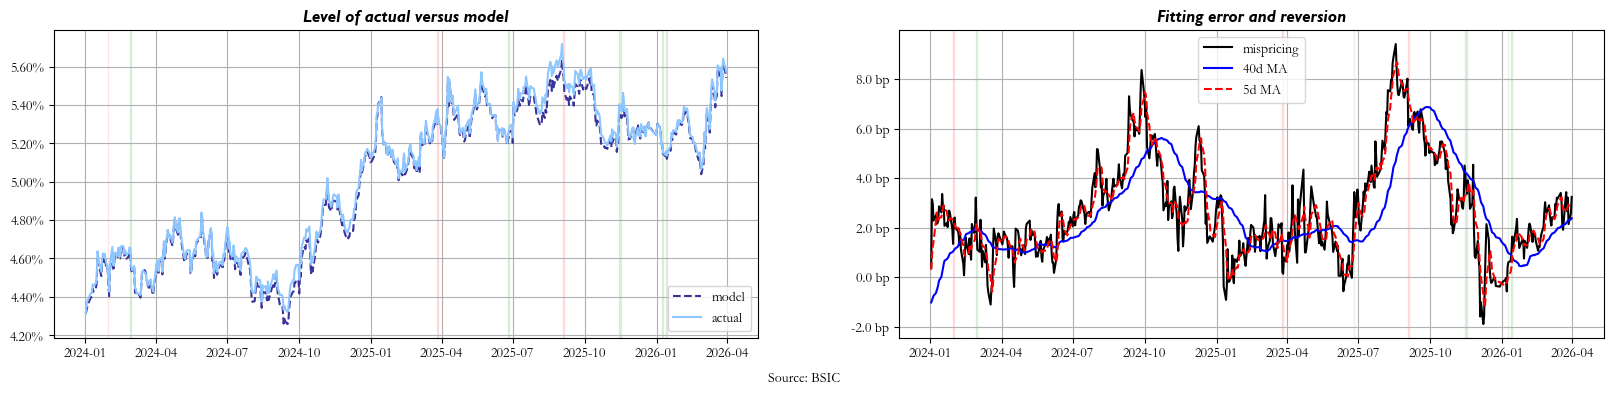

In [27]:
targetTenor = 20
displayStart = '2024-01-01'
displayEnd = None   

bt = screen.singleItemPerformance(modelSeries=screen.modelData[targetTenor],
                                  actualSeries=screen.actualData[targetTenor],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries=screen.modelData[targetTenor],
                         actualSeries = screen.actualData[targetTenor],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= displayStart, display_endDt=displayEnd, backtestDf=bt)

#### 3.3. Attractive curve trades right now

In [56]:
targetSlope = '7s14s'

currentPrice = slopeScreen.loc[targetSlope, 'actual']
targetPrice = slopeScreen.loc[targetSlope, 'model'] + slopeScreen.loc[targetSlope, 'rollMean']
stopLossPrice = targetPrice + 2.5 * slopeScreen.loc[targetSlope, 'rollStd']

print('Current Price: \t', format(currentPrice.round(5) * 100, '.5f'), 'bp')
print('Target Price: \t', format(targetPrice.round(5) * 100, '.5f'), 'bp')
print('Stop Loss: \t', format(stopLossPrice.round(5) * 100, '.5f'), 'bp')

Current Price: 	 67.76200 bp
Target Price: 	 69.06800 bp
Stop Loss: 	 71.71000 bp


   entry_date  exit_date   side  entry_actual    target  stopPrice  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
0  2024-03-14 2024-03-15  SHORT      0.395708  0.398549   0.394351     0.391422    0.036198   0.038425      0.008995     0.008174 -2.095002 -0.452887   True    stop_loss -0.004286     1  False
1  2024-03-20 2024-03-21  SHORT      0.418273  0.421910   0.416579     0.440548    0.035157   0.032921      0.006120     0.005001 -2.147768 -3.468151  False  take_profit  0.022276     1   True
2  2024-03-26 2024-04-02  SHORT      0.430745  0.437121   0.427691     0.448735    0.030965   0.031092      0.000667    -0.001863 -2.088553 -2.047049  False  take_profit  0.017991     7   True
3  2024-05-08 2024-05-09  SHORT      0.406325  0.410928   0.404054     0.423655    0.038699   0.041027      0.003014     0.002422 -2.025661 -1.001133  False  take_profit  0.017329     1   True
4  2024-05-22 2024-05-23  SHORT    

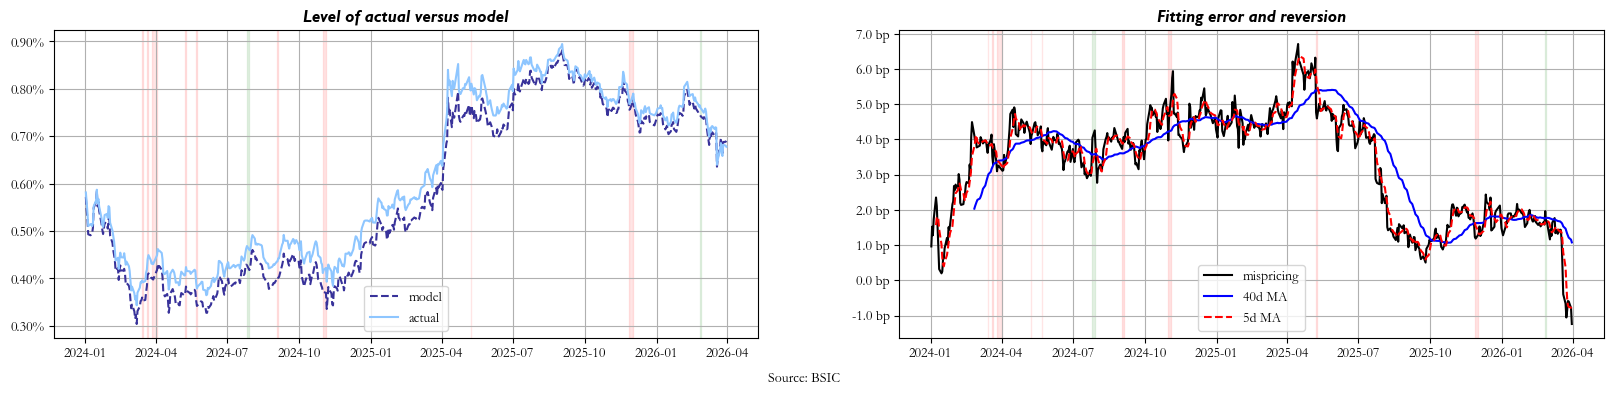

In [57]:
targetSlope = '7s14s'

displayStart = '2024-01-01'

bt = screen.singleItemPerformance(modelSeries=slopeDict['model'][targetSlope],
                                  actualSeries=slopeDict['actual'][targetSlope],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries= slopeDict['model'][targetSlope],
                         actualSeries = slopeDict['actual'][targetSlope],
                         backtestDf = bt,
                         shortW = backtestParams['shortW'], longW = backtestParams['longW'], standardW = backtestParams['standardW'], leftPlotBp = False,
                         startDt = backtestParams['startDt'], endDt = None,
                         display_startDt= displayStart, display_endDt=None)

#### 3.4. Attractive butterfly trades right now

In [ ]:
pd.concat([flyScreen.loc[flyScreen['zscore'].abs() > 1.5].sort_values('zscore').head(10),
           flyScreen.loc[flyScreen['zscore'].abs() > 1.5].sort_values('zscore').tail(10)])

,model,actual,error,signal,rollMean,rollStd,zscore
10s11s12s,-0.012968,-0.007579,0.005389,0.000524,0.005675,0.000134,-2.140699
9s11s13s,-0.052413,-0.029901,0.022512,0.002233,0.023630,0.000574,-1.947736
8s12s16s,-0.182284,-0.123740,0.058544,0.005242,0.060554,0.001226,-1.638329
8s11s14s,-0.119977,-0.065541,0.054437,0.005579,0.056820,0.001480,-1.610709
20s21s22s,-0.003236,-0.004865,-0.001630,0.000031,-0.001770,0.000093,1.512425
19s21s23s,-0.012995,-0.019570,-0.006576,0.000119,-0.007139,0.000366,1.538933
10s17s24s,-0.277042,-0.350498,-0.073456,-0.003470,-0.082277,0.005644,1.562773
7s16s25s,-0.573331,-0.572465,0.000867,0.005866,-0.007539,0.005378,1.562807
11s17s23s,-0.197714,-0.261888,-0.064174,-0.003457,-0.071490,0.004681,1.562920
12s17s22s,-0.134034,-0.184679,-0.050645,-0.002838,-0.056236,0.003537,1.580629


In [ ]:
targetFly = '2.0s13s24s'

currentPrice = flyScreen.loc[targetFly, 'actual']
targetPrice = flyScreen.loc[targetFly, 'model'] + flyScreen.loc[targetFly, 'rollMean']
stopLossPrice = targetPrice + 2.5 * flyScreen.loc[targetFly, 'rollStd']

print('Current Price: \t', format(currentPrice.round(5) * 100, '.5f'), 'bp')
print('Target Price: \t', format(targetPrice.round(5) * 100, '.5f'), 'bp')
print('Stop Loss: \t', format(stopLossPrice.round(5) * 100, '.5f'), 'bp')

Current Price: 	 -51.24400 bp
Target Price: 	 -55.36200 bp
Stop Loss: 	 -37.51300 bp


   entry_date  exit_date   side  entry_actual    target  stopPrice  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
6  2024-02-07 2024-03-05  SHORT      0.346866  0.418325   0.315204     0.504662    0.932852   0.783450      0.033627    -0.163832 -2.256864 -6.975393  False  take_profit  0.157795    27   True
7  2024-03-21 2024-03-27   LONG      0.375029  0.311214   0.404396     0.408118    0.856325   0.862825     -0.065020     0.007313  2.173076  2.394433   True    stop_loss -0.033088     6  False
8  2024-05-07 2024-05-09   LONG      0.412940  0.376274   0.430497     0.349211    0.832170   0.812108     -0.021492    -0.008284  2.088504  0.945785  False  take_profit  0.063729     2   True
9  2024-08-01 2024-08-06   LONG      0.266650  0.185541   0.292768     0.182019    0.857035   0.746296     -0.005077    -0.000484  3.105407 -1.134431  False  take_profit  0.084631     5   True
10 2024-09-11 2024-09-23   LONG    

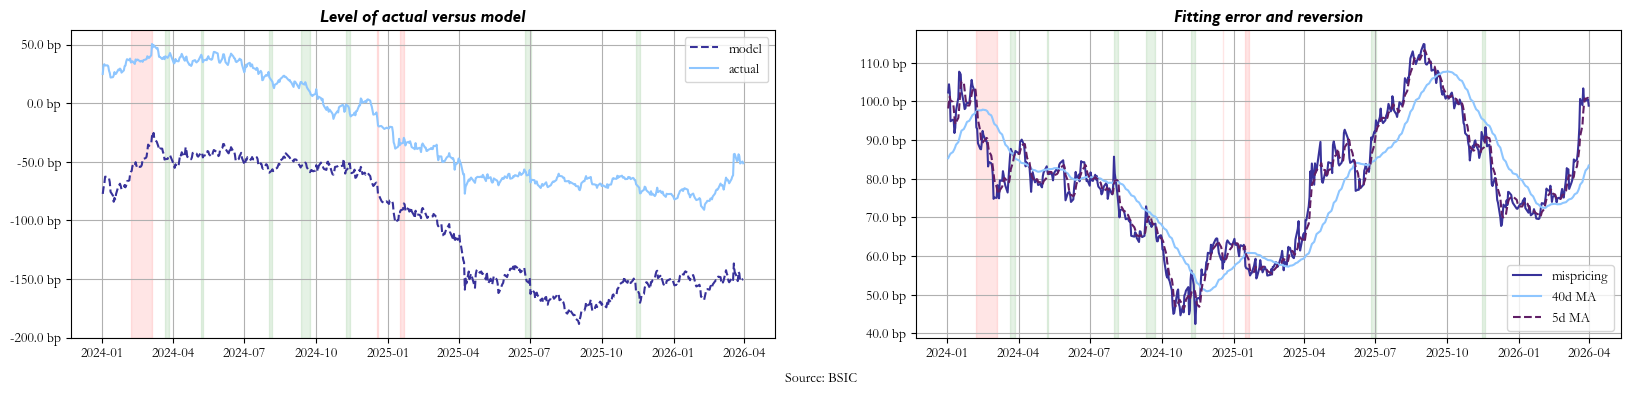

In [ ]:
targetFly = '2.0s13s24s'

displayStart = '2024-01-01'

bt = screen.singleItemPerformance(modelSeries=flyDict['model'][targetFly],
                                  actualSeries=flyDict['actual'][targetFly],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries= flyDict['model'][targetFly],
                         actualSeries = flyDict['actual'][targetFly],
                         backtestDf = bt,
                         shortW = backtestParams['shortW'], longW = backtestParams['longW'], standardW = backtestParams['standardW'], leftPlotBp = True,
                         startDt = backtestParams['startDt'], endDt = None,
                         display_startDt= displayStart, display_endDt=None)

#### 3.5. Does stronger signal = better prediction?

In [58]:
outRightResults = screen.allTradesOutrights(**backtestParams)
outRightResults = pd.concat(outRightResults.values())

slopeResults = screen.allTradesSlopes(**backtestParams, minSpacing = 4)
slopeResults = pd.concat(slopeResults.values())

flyResults = screen.allTradesFlies(**backtestParams, minSpacing = 4)
flyResults = pd.concat(flyResults.values())

allResults = pd.concat([outRightResults, slopeResults, flyResults])

In [59]:
allResults['entry_z_bin'] = pd.qcut(allResults['entry_z'].abs().round(4), q=10, labels = False)
allResults['entry_signal_bin'] = pd.qcut(allResults['entry_signal'].abs().round(4), q=10, labels = False)

In [60]:
heat_hitrate = (allResults.groupby(['entry_z_bin', 'entry_signal_bin'])['hit'].mean().unstack())
heat_pnl = (allResults.groupby(['entry_z_bin', 'entry_signal_bin'])['pnl'].mean().unstack()) * 100


Backtests were run with 2 sigma entry threshold and 1 sigma stop loss threshold,     with stop loss above entry
fonts already added so will not add again


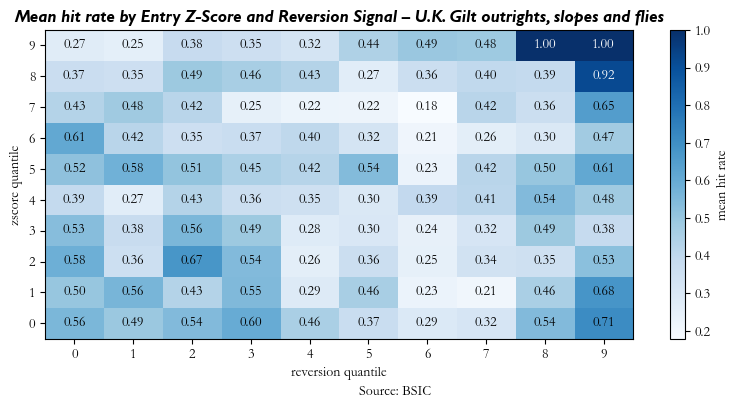

In [61]:
fig, ax = plt.subplots(nrows =1, ncols = 1, figsize=(8, 4))
plotName = 'Mean hit rate by Entry Z-Score and Reversion Signal – U.K. Gilt outrights, slopes and flies'
cmap = 'Blues'
tbl = heat_hitrate.round(3)
im = ax.imshow(tbl.values, aspect='auto', origin='lower', cmap = cmap)
ax.set_xticks(range(len(tbl.columns)))
ax.set_yticks(range(len(tbl.index)))
ax.set_xticklabels(tbl.columns, rotation = 0)
ax.set_yticklabels(tbl.index)
ax.set_xlabel('reversion quantile')
ax.set_ylabel('zscore quantile')
ax.set_title(plotName)


cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f'mean hit rate')

norm = im.norm
center = 0.05 * (norm.vmax + norm.vmin)
threshold = 0.8 * (abs(norm.vmax) - abs(norm.vmin))  # tweak 0.25

for x in range(tbl.shape[0]):
    for j in range(tbl.shape[1]):
        val = tbl.iloc[x, j]
        if pd.notna(val):
            color = "white" if abs(val - center) > abs(threshold) else "black"
            ax.text(j, x, f'{val:.2f}', ha='center', va='center', color = color)

plt.tight_layout()
print(f'Backtests were run with {backtestParams['numberSigma']} sigma entry threshold and {backtestParams['stopLossSigma']} sigma stop loss threshold, \
    with {"stop loss above entry" if backtestParams["stopLossAboveEntry"] else "stop loss below entry"}')
bsic.apply_bsic_style(fig, ax)
plt.savefig('plots/gilt/heatmap_hitRateByEntrySignal.png', dpi = 300)
bsic.export_figure(fig, 'plots/gilt/heatmap_hitRateByEntrySignal')

### 4. Time series of the residuals

In [80]:
oosFittingErrors = fittingErrors_2024['2024-01-01':]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:2085: RuntimeWarning: Mean of empty slice.
  resids = x - x.mean()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:2175: RuntimeWarning: invalid value encountered in scalar divide
  s0 = np.sum(resids ** 2) / nobs


Text(0.5, 1.0, 'PP p-values')

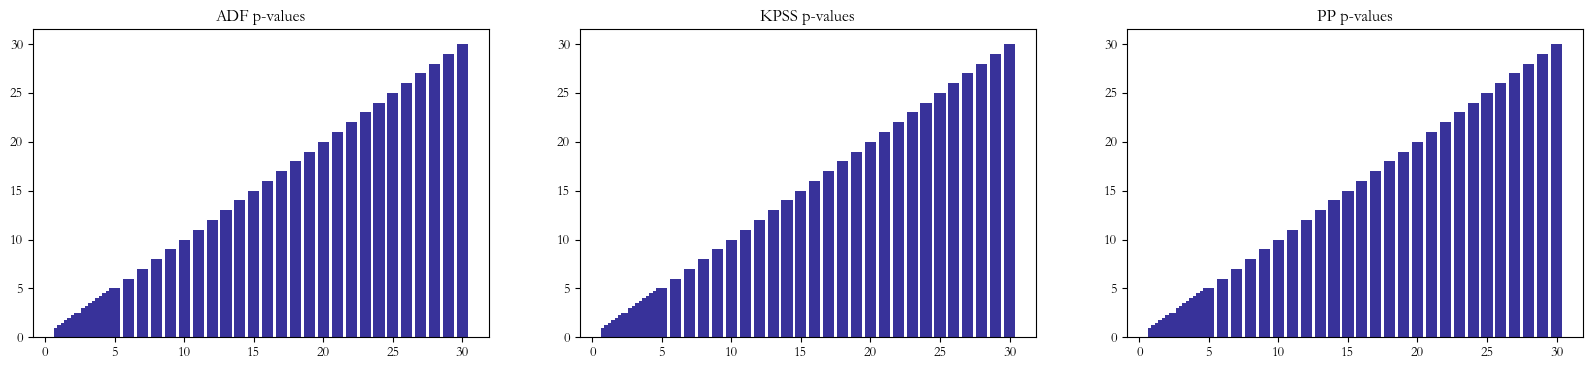

In [44]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 4))
ax[0].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: adfuller(x.dropna(), autolag = 'BIC', regression = 'c')[1]));
ax[0].set_title('ADF p-values')
ax[1].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
ax[1].set_title('KPSS p-values')
ax[2].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: PhillipsPerron(x.dropna(), trend = 'c').pvalue));
ax[2].set_title('PP p-values')

It seems that all tests agree that fitting errors below 15y are nonstationary. Then ADF and PP say that long-end fitting errors are stationary.

fonts already added so will not add again


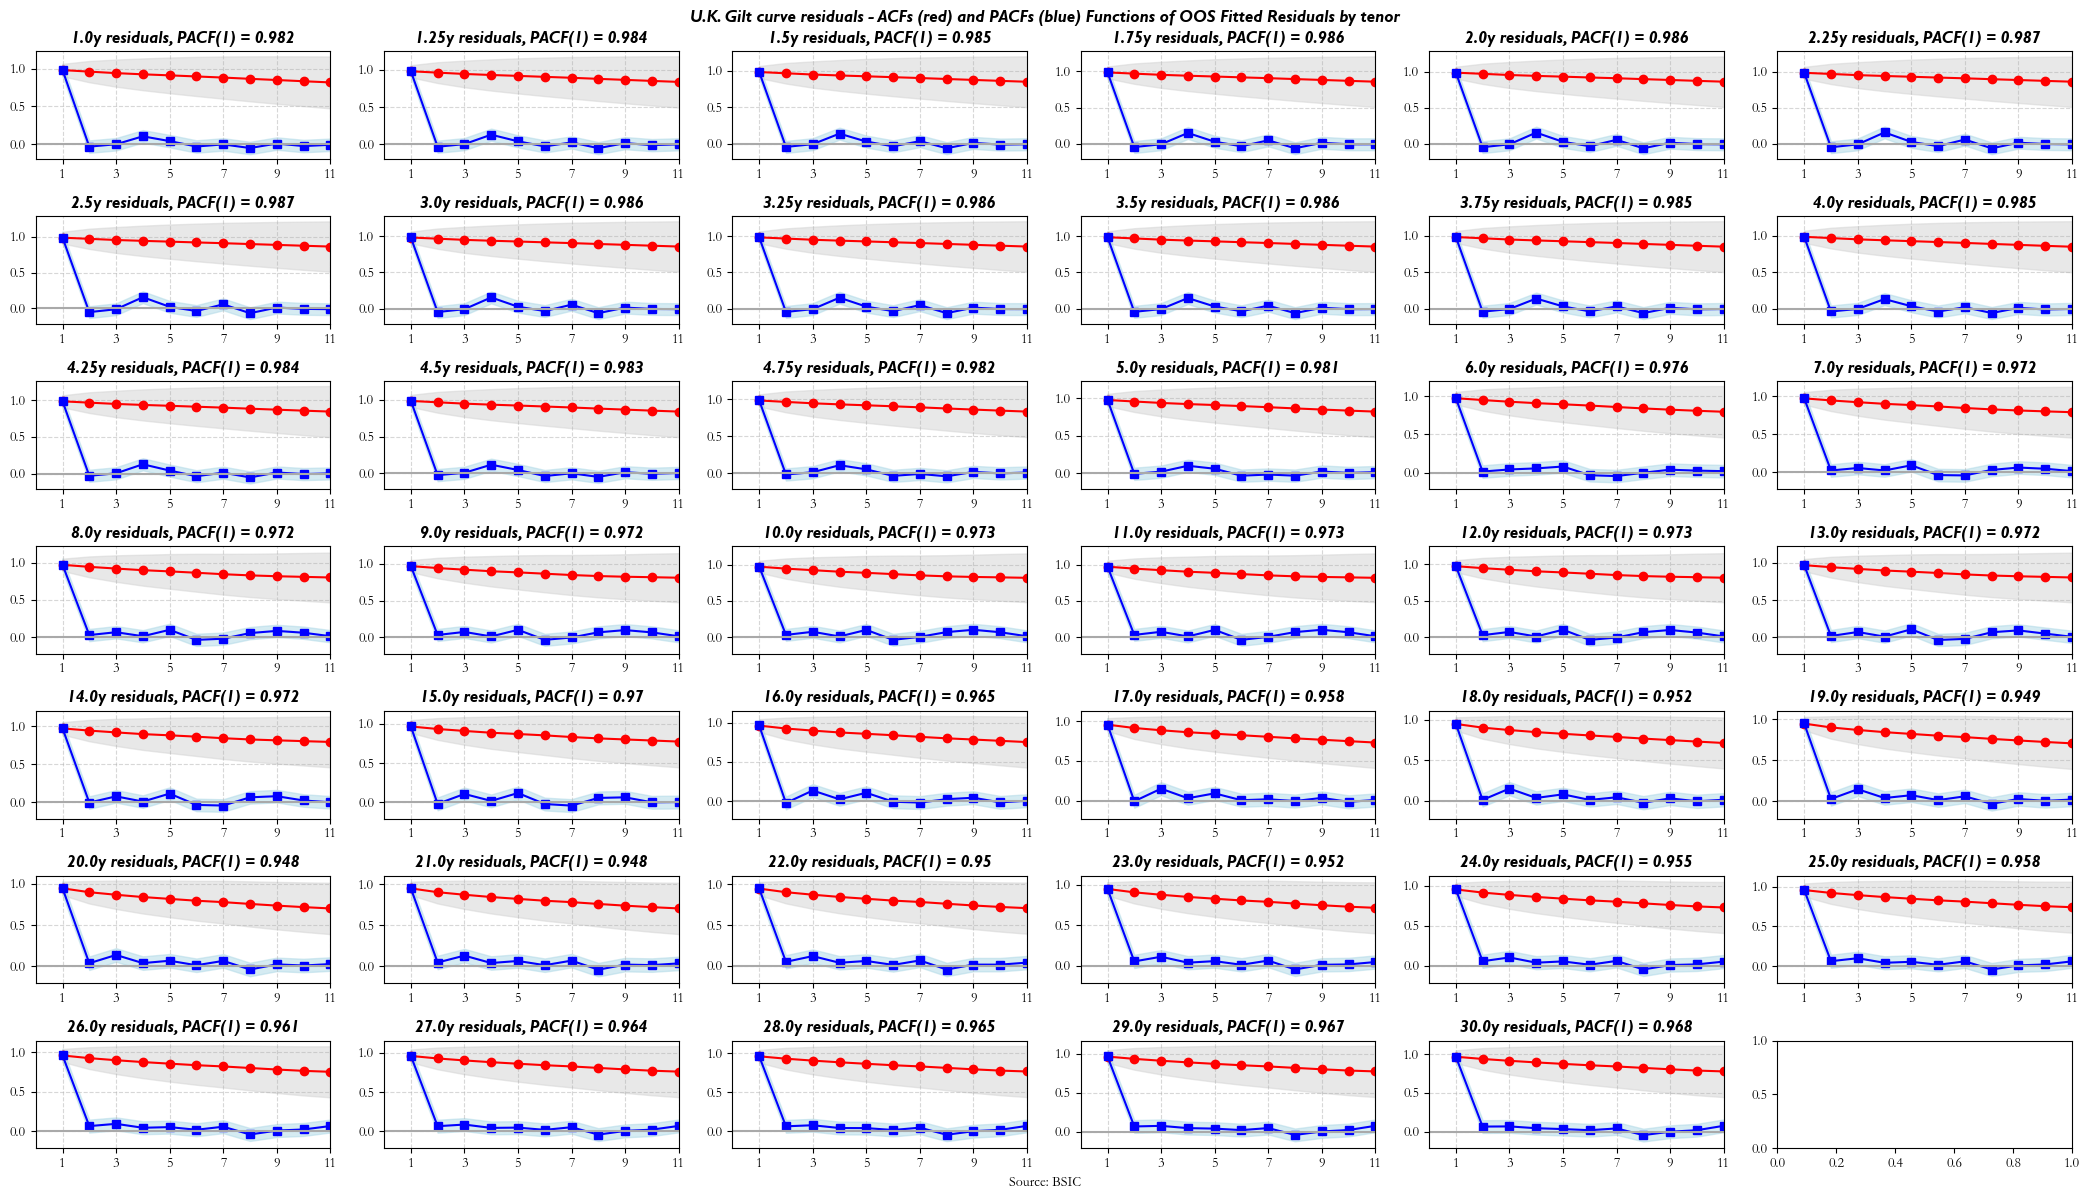

In [124]:
fig, ax = plt.subplots(nrows = 7, ncols = 6, figsize = (21, 12))
ax = ax.flatten()
fig.suptitle('U.K. Gilt curve residuals - ACFs (red) and PACFs (blue) Functions of OOS Fitted Residuals by tenor')
bsic.apply_bsic_style(fig, ax)
i = 0
for tenor in oosFittingErrors.columns:
    sampleAcf, acfCI = acf(oosFittingErrors[tenor].dropna(), alpha = 0.05)
    sampleAcf = sampleAcf[1:]
    samplePacf, pacfCI = pacf(oosFittingErrors[tenor].dropna(), alpha = 0.05)
    samplePacf = samplePacf[1:]
    pacfCI = pacfCI[1:]
    acfCI = acfCI[1:]
    ax[i].plot(sampleAcf, marker = 'o', color = 'red')
    ax[i].plot(samplePacf, marker = 's', color = 'blue')
    ax[i].fill_between(range(len(sampleAcf)), acfCI[:, 0], acfCI[:, 1], color = 'lightgrey', alpha = 0.5)
    ax[i].fill_between(range(len(samplePacf)), pacfCI[:, 0], pacfCI[:, 1], color = 'lightblue', alpha = 0.5)
    ax[i].axhline(y = 0, color = 'darkgrey')
    ax[i].set_title(f'{tenor}y residuals, PACF(1) = {samplePacf[0].round(3)}')
    
    ax[i].set_xticks(range(0, len(sampleAcf), 2))
    ax[i].set_xticklabels(range(1, len(sampleAcf)+1, 2))
    ax[i].set_xlim(-1, 10)
    ax[i].grid(True, which = 'both', linestyle = '--', alpha = 0.5)
    i += 1

plt.tight_layout(rect=[0, 0, 1, 1.0])
plt.savefig('plots/gilt/residualsACF_PACF.png', dpi = 300)
bsic.export_figure(fig, 'plots/gilt/residualsACF_PACF')


In [127]:
autoReg_coefficients = {}
act_halflives = {}
MAXLAG_AR =2
for tenor in oosFittingErrors.columns:
    df = pd.DataFrame()
    df['series'] = oosFittingErrors[tenor]
    for L in range(1, MAXLAG_AR + 1):
        df[f'series.lag{L}'] = df['series'].shift(L)
    df = df.dropna()
    model_ar1 = smf.OLS(endog = df['series'], exog = smf.add_constant(df[['series.lag1']])).fit()
    model = smf.OLS(endog = df['series'], exog = smf.add_constant(df[[f'series.lag{i}' for i in range(1, MAXLAG_AR + 1)]])).fit()
    autoReg_coefficients[tenor] = model_ar1.params['series.lag1']
    phi = model.params.values[1:]
    psiStore = [0 for _ in range(MAXLAG_AR-1)] + [1]
    curr_psi = 1
    while abs(curr_psi) > 0.5:
        curr_psi = sum([phi[i] * psiStore[-1 - i] for i in range(MAXLAG_AR)])
        psiStore.append(curr_psi)
    act_halflives[tenor] = len(psiStore) - MAXLAG_AR - 1

    

Indeed if we model residuals as AR(1), their $\phi$ is very close to 1, and hence they're not the most tradable.

In [128]:
pd.DataFrame([autoReg_coefficients, 
              {key: np.log(0.5)/np.log(abs(value)) for key, value in autoReg_coefficients.items()},
              act_halflives], index = ['AR(1) coefficient', 'AR(1) half-life in days', f'AR({MAXLAG_AR}) actual half-lives']).T

,AR(1) coefficient,AR(1) half-life in days,AR(2) actual half-lives
1.00,0.987708,56.040690,54.0
1.25,0.989673,66.773434,64.0
1.50,0.990542,72.942085,70.0
1.75,0.990922,76.007821,72.0
2.00,0.991078,77.341003,73.0
2.25,0.991131,77.802693,74.0
2.50,0.991135,77.841686,74.0
3.00,0.991078,77.341003,73.0
3.25,0.991030,76.926111,73.0
3.50,0.990971,76.419240,73.0


/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_3717/3252727184.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels())
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_3717/3252727184.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels())
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_3717/3252727184.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels())


fonts already added so will not add again


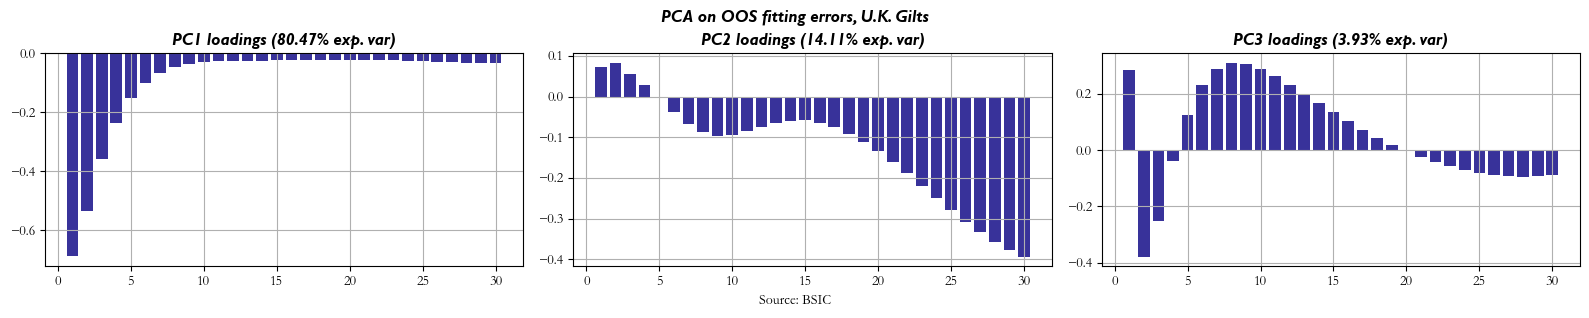

In [97]:
pcaObject = PCA()
pcaData = oosFittingErrors[[x for x in MATURITIES if not (str(x).__contains__('.25') or str(x).__contains__('.5') or str(x).__contains__('.75'))]]
pcaObject.fit(pcaData.values);

fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (16, 3))
for i in range(0,3):
    ax[i].bar(pcaData.columns, -1 * pcaObject.components_[i])
    ax[i].set_title(f'PC{i+1} loadings ({pcaObject.explained_variance_ratio_[i]:.2%} exp. var)')
    ax[i].set_xticklabels(ax[i].get_xticklabels())
    ax[i].grid(True)

plt.suptitle('PCA on OOS fitting errors, U.K. Gilts')
plt.tight_layout(rect=[0, 0, 1, 1.05])
bsic.apply_bsic_style(fig, ax)
bsic.export_figure(fig, 'plots/gilt/pca_fittingErrors.png')
plt.savefig('plots/gilt/pca_fittingErrors.png', dpi = 300)

### 5. Attractive Right Now

#### 5.1 Factor sensitivities of a trade

In [ ]:
marketValuePositions = {10: 1 * 10_000_000}

yields = {10: zeroCouponYields[10].iloc[-1]}

screen.factorSensitivity(marketValuePositions=marketValuePositions,
                         yields = yields,
                         pricer = fittedPricer_2024)

,position,market value,mod duration,DV01,short sensitivity,medium sensitivity,long sensitivity,short DV01,medium DV01,long DV01
tenor,,,,,,,,,,
10.0,long,"10,000,000",9.528874,"-9,529",0.049261,0.243233,0.666168,-469,"-2,318","-6,348"
Total,,,,,,,,-469,"-2,318","-6,348"


In [ ]:
marketValuePositions = {20: 2 * 10_000_000, 
                        30: -1 * 10_000_000, 
                        10: -1 * 10_000_000}

yields = {20: zeroCouponYields[20].iloc[-1], 
          30: zeroCouponYields[30].iloc[-1], 
          10: zeroCouponYields[10].iloc[-1]}

screen.factorSensitivity(marketValuePositions=marketValuePositions,
                         yields = yields,
                         pricer = fittedPricer_2024)

,position,market value,mod duration,DV01,short sensitivity,medium sensitivity,long sensitivity,short DV01,medium DV01,long DV01
tenor,,,,,,,,,,
20.0,long,"20,000,000",18.944046,"-37,888",0.024631,0.124353,0.745731,-933,"-4,712","-28,254"
30.0,short,"-10,000,000",28.400127,"28,400",0.01642,0.082935,0.734217,466,"2,355","20,852"
10.0,short,"-10,000,000",9.528874,"9,529",0.049261,0.243233,0.666168,469,"2,318","6,348"
Total,,,,,,,,3,-38,"-1,055"


In [ ]:
marketValuePositions = {20: 1.9 * 10_000_000, 
                        30: -1 * 10_000_000, 
                        10: -1 * 10_000_000}

yields = {20: zeroCouponYields[20].iloc[-1], 
          30: zeroCouponYields[30].iloc[-1], 
          10: zeroCouponYields[10].iloc[-1]}

screen.factorSensitivity(marketValuePositions=marketValuePositions,
                         yields = yields,
                         pricer = fittedPricer_2024)

,position,market value,mod duration,DV01,short sensitivity,medium sensitivity,long sensitivity,short DV01,medium DV01,long DV01
tenor,,,,,,,,,,
20.0,long,"19,000,000",18.944046,"-35,994",0.024631,0.124353,0.745731,-887,"-4,476","-26,842"
30.0,short,"-10,000,000",28.400127,"28,400",0.01642,0.082935,0.734217,466,"2,355","20,852"
10.0,short,"-10,000,000",9.528874,"9,529",0.049261,0.243233,0.666168,469,"2,318","6,348"
Total,,,,,,,,49,197,358


In [ ]:
weightedFly_model = screen.modelData[20] * 1.9 - screen.modelData[30] - screen.modelData[10]
weightedFly_actual = screen.actualData[20] * 1.9 - screen.actualData[30] - screen.actualData[10]

bt = screen.singleItemPerformance(modelSeries = weightedFly_model,
                             actualSeries = weightedFly_actual,
                             **backtestParams)

print(bt['hit'].mean())
print(bt.loc[bt['hit'] == 1]['pnl'].mean() / abs(bt.loc[bt['hit'] == 0]['pnl']).mean())

0.5571428571428572
1.0932983424847122


   entry_date  exit_date   side  entry_actual    target  stopPrice  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
48 2025-01-24 2025-01-31   LONG      0.015751  0.003125   0.023497     0.035855    0.219745   0.221760     -0.006315    -0.003573  1.630133  1.890272   True    stop_loss -0.020104     7  False
49 2025-02-03 2025-02-04   LONG      0.045995  0.038575   0.052782     0.036329    0.218365   0.207122     -0.002384    -0.002955  1.093195 -0.563345  False  take_profit  0.009666     1   True
50 2025-02-10 2025-02-11   LONG      0.043191  0.037320   0.048223     0.029844    0.219194   0.211877     -0.003432    -0.002104  1.166667 -0.287269  False  take_profit  0.013347     1   True
51 2025-03-17 2025-03-25   LONG      0.030885  0.013804   0.039286     0.042584    0.202892   0.209869     -0.012394     0.006069  2.033274  2.863709   True    stop_loss -0.011699     8  False
52 2025-04-30 2025-05-02  SHORT    

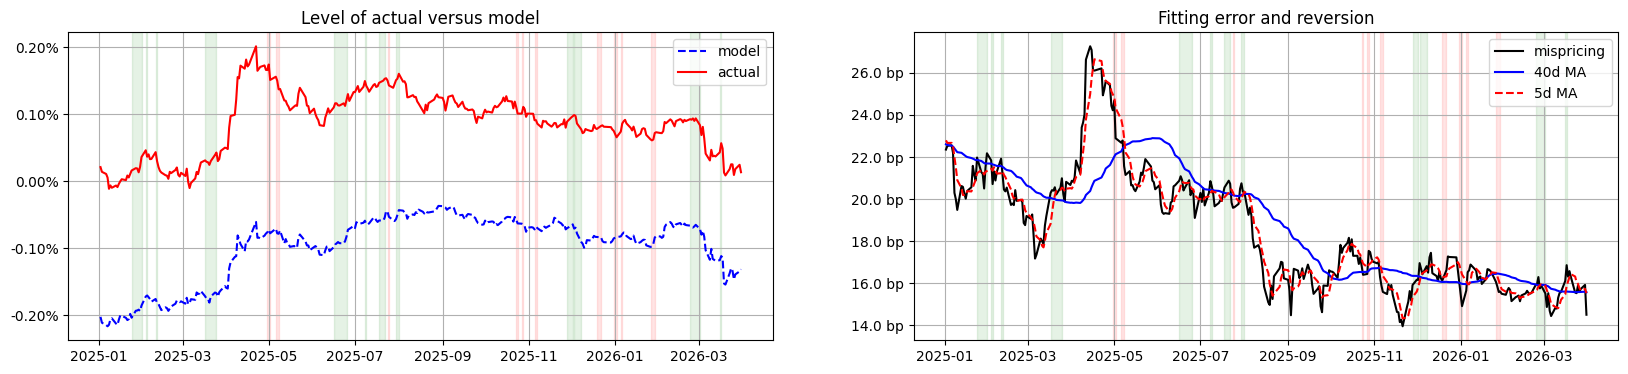

In [ ]:
displayStart = '2025-01-01'
print(bt.loc[bt['entry_date'] >= displayStart].to_string())
screen.plotModelVsActual(modelSeries= weightedFly_model,
                         actualSeries = weightedFly_actual,
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= displayStart, display_endDt=None, backtestDf=bt)